# Mapping MeSH descriptors to AOP Key Events (KEs)

#### Goal

Map MeSH descriptors to KEs from the AOP-Wiki database using Natural Language Processing, semantic search and indexing to identify correspondences between MeSH descriptors and AOP Key Events.

#### AOP Key Events 

- Extracted from AOP-Wiki  
- Includes KEs with detailed textual descriptions capturing biological processes, molecular events, or cellular responses  
- Some KEs only contain titles, as no public descriptions are available  

#### Environment set up

The following libraries are required for data manipulation, NLP tasks, data visualisation, evaluation metrics, and querying external resources.

In [169]:
# load libraries
import pandas as pd
from rapidfuzz import fuzz, process
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
from collections import defaultdict
import nltk
from sklearn import metrics
from nltk.corpus import stopwords
from scipy.stats import kendalltau

# ==============================
# Data handling
# ==============================
import pandas as pd
import numpy as np
from collections import Counter
from rdflib import Graph, Literal, URIRef, Namespace, DC, DCTERMS, RDF
from rdflib.namespace import XSD

# ==============================
# NLP and semantic similarity
# ==============================
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModel
from transformers import logging as hf_logging

# ==============================
# NLP preprocessing
# ==============================
import nltk

# ==============================
# Machine Learning / evaluation
# ==============================
from sklearn import metrics
import torch
from scipy.stats import spearmanr, kendalltau

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# External data access
# ==============================
from SPARQLWrapper import SPARQLWrapper, JSON

## 1. Retrieve MeSH descriptors from the MeSH RDF SPARQL endpoint

- We query the [NLM MeSH SPARQL endpoint](https://id.nlm.nih.gov/mesh/sparql) to build our reference vocabulary. We are interested in *TopicalDescriptors*.  
- We first run a `COUNT` query to verify the number of currently active descriptors, then iterate over the full set (using `LIMIT / OFFSET`) to retrieve their *labels* and *tree numbers*. Tree numbers encode each descriptor's position in the MeSH hierarchy: we extract the first letter as a proxy for its top-level branch (e.g. C → Diseases, D → Chemicals).  
- Finally, we plot a quick overview of the vocabulary: the distribution of descriptor title lengths (relevant for tokenisation) and the frequency of descriptors per branch.

In [2]:
# Define the endpoint URL
mesh_endpoint_url = "https://id.nlm.nih.gov/mesh/sparql"

In [3]:
# Count total active MeSH TopicalDescriptors available on the SPARQL endpoint.
# We use COUNT(DISTINCT ?d) to avoid duplicates, filtering on mesh:active 1 to exclude deprecated descriptors.
query = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX meshv: <http://id.nlm.nih.gov/mesh/vocab#>
PREFIX mesh: <http://id.nlm.nih.gov/mesh/>
SELECT (COUNT(DISTINCT ?d) AS ?totalMeSH)
WHERE {
    ?d a meshv:TopicalDescriptor .
    ?d meshv:active 1 .
}
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(mesh_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Print the count (useful as a sanity check before starting the full retrieval)
for result in results["results"]["bindings"]:
    print(result["totalMeSH"]["value"] + " active MeSH descriptors are currently available on the MeSH RDF SPARQL endpoint.")

30512 active MeSH descriptors are currently available on the MeSH RDF SPARQL endpoint.


In [4]:
# The endpoint does not support unbounded queries, so we query in batches of 1000 rows, incrementing the offset until no results are returned. 
data = []
limit = 1000
offset = 0

while True:
    # Fetch one batch of descriptors URIs and their rdfs:label (human-readable title)
    paginated_query = f"""
    PREFIX meshv: <http://id.nlm.nih.gov/mesh/vocab#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

    SELECT ?d ?title
    FROM <http://id.nlm.nih.gov/mesh>
    WHERE {{
        ?d a meshv:TopicalDescriptor .
        ?d meshv:active 1 .
        ?d rdfs:label ?title .
    }}
    LIMIT {limit} OFFSET {offset}
    """
    sparql.setQuery(paginated_query)
    results = sparql.query().convert()
    bindings = results["results"]["bindings"]

    if not bindings:
        break  # Empty page = all descriptors have been retrieved

    # Store the descriptor URI and label for each result in the current batch
    for result in bindings:
        data.append({
            "MESH_ID": result["d"]["value"],
            "MESH_TITLE": result["title"]["value"]
        })

    offset += limit # Go on to the next batch

# Collect all descriptors into a DataFrame
MeSH_descriptors = pd.DataFrame(data)

In [5]:
# Same batch pattern as above, this tile retrieveing tree numbers
data = []
limit = 1000
offset = 0

while True:
    # Fetch one batch of descriptor URIs and their associated tree numbers
    paginated_query = f"""
    PREFIX meshv: <http://id.nlm.nih.gov/mesh/vocab#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

    SELECT ?d ?tree
    FROM <http://id.nlm.nih.gov/mesh>
    WHERE {{
        ?d a meshv:TopicalDescriptor .
        ?d meshv:active 1 .
        ?d meshv:treeNumber ?tree .
    }}
    LIMIT {limit} OFFSET {offset}
    """
    sparql.setQuery(paginated_query)
    results = sparql.query().convert()
    bindings = results["results"]["bindings"]

    if not bindings:
        break  # Empty page = all descriptors have been retrieved

    # Store the descriptor URI and tre number for each result in the current batch
    for result in bindings:
        data.append({
            "MESH_ID": result["d"]["value"],
            # Tree numbers are returned as full URIs; we strip the base URL and keep
            # only the first character, which identifies the top-level branch (e.g. "C", "D")
            "MESH_BRANCH": result["tree"]["value"].replace("http://id.nlm.nih.gov/mesh/", "")[0]
        })

    offset += limit # Go on to the next batch

# Collect into a DataFrame 
# /!\ One descriptor can have multiple tree numbers, producing duplicate MESH_ID rows at this stage
MeSH_branches = pd.DataFrame(data)
# Keep only one branch per descriptor (the first one encountered after grouping)
MeSH_branches = MeSH_branches.groupby("MESH_ID")["MESH_BRANCH"].first().reset_index()

In [6]:
# Prepare list of descriptors titles
MeSH_descriptors_titles = MeSH_descriptors["MESH_TITLE"].unique().tolist()

### Vocabulary overview

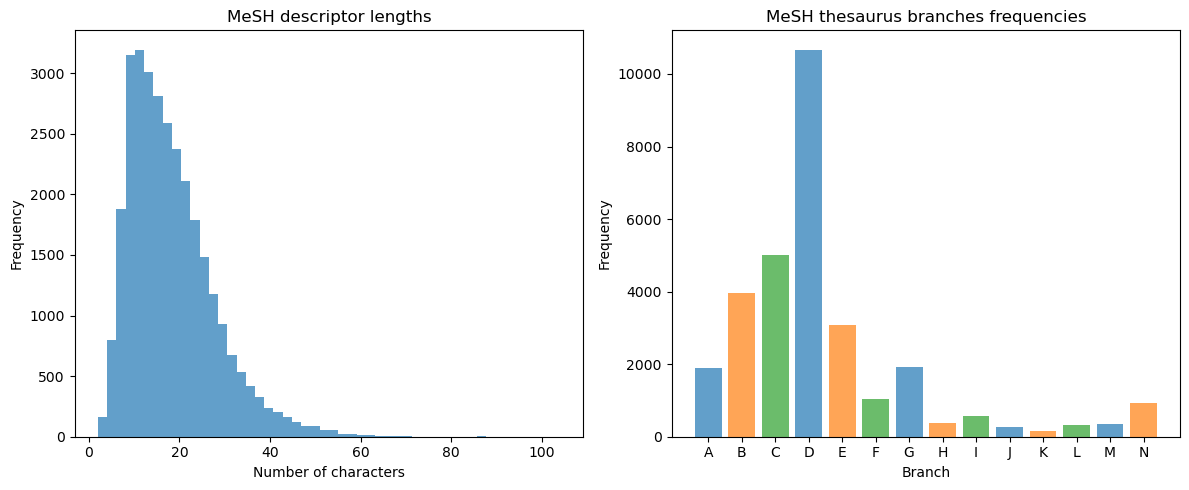

In [7]:
# Compute the character lengths of each MeSH descriptor title
MeSH_descriptors_lengths = [len(x) for x in MeSH_descriptors_titles]

# Count how many descriptors fall into each top-level branch
freq = Counter(MeSH_branches["MESH_BRANCH"])
labels = sorted(freq.keys())
counts = [freq[k] for k in labels]

# Side by side plots for quick vocabulary overview
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left : histogram of descriptors titles lengths (character count)
axes[0].hist(MeSH_descriptors_lengths, bins=50, alpha=0.7, color="C0")
axes[0].set_title("MeSH descriptor lengths")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Number of characters")

# Right : bar chart of descriptor counts per top-level branch
axes[1].bar(labels, counts, color=["C0", "C1", "C2"], alpha=0.7)
axes[1].set_title("MeSH thesaurus branches frequencies")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Branch")
plt.tight_layout()
plt.show()

- The distribution of descriptors lengths shows that most MeSH descriptors are fairly short terms (peaking around 10-15 characters). The tail extends to ~ 100 characters, there is a minority of long descriptors.  
- The thesaurus branch D (*Chemicals and Drugs*) is by far the most represented, with 10,669 descriptors (34.9% of total descriptors). Branches C (*Diseases*, 16.4%), B (*Organisms*, 12.9%), E (*Analytical, Diagnostic and Therapeutic Techniques, and Equipment*, 10.1%), G (*Phenomena and Processes*, 6.3%), A (*Anatomy*, 6.2%) are the next most populated. Remaining branches are sparse.  

## 2. Retrieve Key Events from the AOP-wiki SPARQL endpoint

This section connects to the AOP-wiki SPARQL endpoint to retrieve information about Key Events in AOPs.  
The workflow includes 3 main steps:   
- **Count total Key Events**: execute a SPARQL query to count all Key Events available on the AOP-wiki endpoint.  
- **Retrieve Key Events with descriptions**: queries for Key Events that have a publicly available description, along with their title, description and the AOP they belong to, then builds a Pandas Dataframe to store them.  
- **Retrieve Key Events without descriptions**: queries for Key Events that do **not** have a description and store them in a Pandas Dataframe.  

In [8]:
# Define the endpoint URL
aop_endpoint_url = "https://aopwiki.rdf.bigcat-bioinformatics.org/sparql/"

In [9]:
# Count the total number of Key Events (KEs) available on the AOP-wiki SPARQL endpoint.
query = """
SELECT (COUNT(DISTINCT ?ke) AS ?totalKE)
WHERE {
    ?ke a aopo:KeyEvent .
}
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(aop_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Print the count (useful as a sanity check before starting the full retrieval)
for result in results["results"]["bindings"]:
    print(result["totalKE"]["value"] + " AOP Key Events are currently available on the AOP-wiki SPARQL endpoint.")

1571 AOP Key Events are currently available on the AOP-wiki SPARQL endpoint.


In [10]:
# Retrieve all Key Events that have a publicly available description.
# /!\ Not all KEs expose a dc:description, so this query will return fewer entries than the total KE count above.
query = """
SELECT ?ke ?ketitle ?description
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dc:title ?ketitle .
    ?ke dc:description ?description .
} 
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(aop_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Parse the results into a flat list of dicts, one per KE
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_title = result["ketitle"]["value"]
    ke_description = result["description"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "KE_TITLE" : ke_title,
        "KE_DESCRIPTION" : ke_description
    })

# Load results into a DataFrame (one row per KE)
AOP_KEs_description = pd.DataFrame(data)

# Report how many KEs have a description
unique_ke_ids = AOP_KEs_description["KE_ID"].unique()
print(f"{len(unique_ke_ids)} Key Events have publicly available descriptions.")

626 Key Events have publicly available descriptions.


Only 39.8% of Key Events have a publicly available description.

In [11]:
# Retrieve all Key Events that do NOT have a publicly available description.
# FILTER NOT EXISTS excludes any KE for which a dc:description triple exists.
query = """
SELECT ?ke ?ketitle 
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dc:title ?ketitle .
    FILTER NOT EXISTS { ?ke dc:description ?d . }
} 
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(aop_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Parse the results into a flat list of dicts, one per KE
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_title = result["ketitle"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "KE_TITLE" : ke_title
    })

# Load results into a DataFrame (one row per KE)
AOP_KEs_no_description = pd.DataFrame(data)

# Report the count
unique_ke_ids = AOP_KEs_no_description["KE_ID"].unique()
print(f"{len(unique_ke_ids)} Key Events do not have a publicly available description.")

945 Key Events do not have a publicly available description.


In [12]:
# Retrieve the AOP(s) each Key Event belongs to via the dcterms:isPartOf predicate.
# A single KE can be shared across multiple AOPs.
query = """
SELECT ?ke ?aop ?aoptitle
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dcterms:isPartOf ?aop .
    ?aop dc:title ?aoptitle
} 
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(aop_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Parse results into a flat list of dicts, one row per (KE, AOP) pair
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_aop = result["aop"]["value"]
    aop_title = result["aoptitle"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "AOP_ID" : ke_aop,
        "AOP_TITLE" : aop_title
    })

# Load results into a DataFrame
KE_to_AOP = pd.DataFrame(data)

Before performing further analyses, we convert the retrieved Key Events data (titles and descriptions) into lists for easier manipulation, filtering, and iteration in subsequent steps. We also check the length distributions of the title and description Strings.

In [13]:
# Prepare lists
ke_titles_description = AOP_KEs_description["KE_TITLE"].unique().tolist()
ke_titles_no_description = AOP_KEs_no_description["KE_TITLE"].unique().tolist()
ke_descriptions = AOP_KEs_description["KE_DESCRIPTION"].unique().tolist()

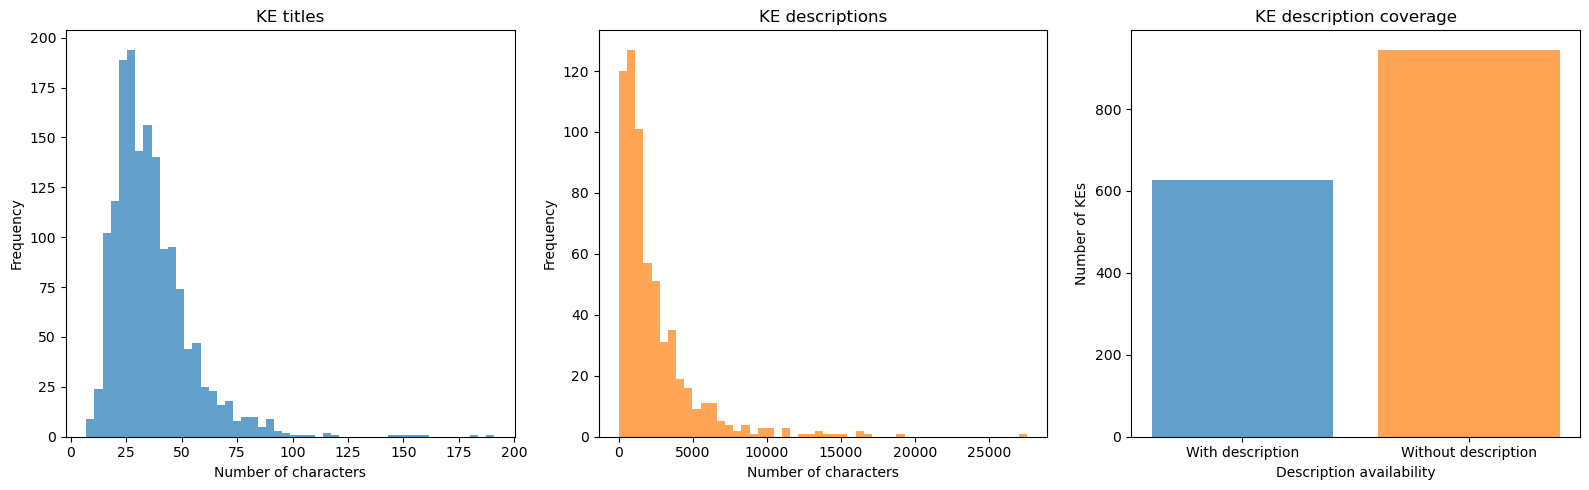

In [14]:
# Compute character lengths for KE titles (across all KEs) and descriptions (publicly available KEs only)
ke_titles_lengths = [len(x) for x in ke_titles_description + ke_titles_no_description]
ke_descriptions_lengths = [len(x) for x in ke_descriptions]

# Count KEs with and without descriptions for the coverage bar chart
n_with = len(ke_titles_description)
n_without = len(ke_titles_no_description)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left : distribution of KE title lengths
axes[0].hist(ke_titles_lengths, bins=50, alpha=0.7, color="C0")
axes[0].set_title("KE titles")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Number of characters")

# Middle : distribution of KE description lengths
axes[1].hist(ke_descriptions_lengths, bins=50, alpha=0.7, color="C1")
axes[1].set_title("KE descriptions")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Number of characters")

# Right : bar chart of KEs with vs without a public description
axes[2].bar(["With description", "Without description"], [n_with, n_without], color=["C0", "C1"], alpha=0.7)
axes[2].set_title("KE description coverage")
axes[2].set_ylabel("Number of KEs")
axes[2].set_xlabel("Description availability")

plt.tight_layout()
plt.show()

## 3. Indexing on Key Events with publicly available descriptions

In this section, we build an indexer to retrieve relevant standardised MeSH (Medical Subject Headings) descriptors based on Key Events. This is applied only to Key Events that have a publicly available description, since the indexing relies on textual content.  
We use the [Wellcome/WellcomeBertMesh](https://huggingface.co/Wellcome/WellcomeBertMesh) model as the underlying annotator. This model is based on [BiomedBERT](https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract) and was originally trained in the BioASQ competition to annotate biomedical texts with MeSH descriptors. While it was designed for research grants, it generalises well to any biomedical text, including AOP Key Event descriptions.

- **Input**: a Dataframe containing Key Events descriptions. For each Key Event, we use the description as input.  
- **Process**:
    - Each Key Event description is tokenised using the WellcomeBertMesh tokenizer, with padding and truncation to a fixed length.  
    - The tonekised text is fed into the WellcomeBertMesh, and predictions are generated.  
    - The model outputs predicted MeSH descriptors for the Key Event description.  
- **Output**: a list of dictionaires where each entry contains the Key Event ID and a list of predicted MeSH descriptors associated with that Key Event.

In [15]:
# Load the WellcomeBertMesh tokenizer and model from the Hugging Face Hub
wellcomeBertMesh_tokenizer = AutoTokenizer.from_pretrained("Wellcome/WellcomeBertMesh")
wellcomeBertMesh_model = AutoModel.from_pretrained("Wellcome/WellcomeBertMesh", trust_remote_code = True)
# trust_remote_code = True is required as the model uses custom inference logic hosted on the Hub

Some weights of the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract were not used when initializing BertModel: ['cls.predictions.decoder.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [33]:
def chunk_text(text, tokenizer, chunk_size=512, overlap=50):
    """Split token IDs into overlapping chunks of chunk_size."""
    
    # Suppress the spurious 'sequence longer than max_length' warning
    # We are intentionally encoding the full text before manually chunking it
    prev_verbosity = hf_logging.get_verbosity()
    hf_logging.set_verbosity_error()
    tokens = tokenizer.encode(text, add_special_tokens=False)
    hf_logging.set_verbosity(prev_verbosity)  # restore original verbosity

    chunks = []
    step = chunk_size - overlap - 2  # reserve 2 tokens for [CLS] and [SEP]
    for start in range(0, len(tokens), step):
        chunk = tokens[start : start + chunk_size - 2]
        chunks.append(chunk)
        if start + chunk_size - 2 >= len(tokens):
            break
    return chunks

def predict_long_text(text, model, tokenizer, chunk_size=512, overlap=50):
    """Run inference on each chunk and union all predicted MeSH labels."""
    chunks = chunk_text(text, tokenizer, chunk_size, overlap)
    all_labels = set()

    for chunk_ids in chunks:
        # Re-add special tokens and pad to max_length
        inputs = tokenizer.prepare_for_model(
            chunk_ids,
            padding="max_length",
            truncation=True,
            max_length=chunk_size,
            return_tensors="pt"
        )
        # Add batch dimension
        inputs = {k: v.unsqueeze(0) for k, v in inputs.items()}

        labels = model(**inputs, return_labels=True)
        all_labels.update(labels[0])

    return list(all_labels)

### Basic indexing

In [ ]:
indexing_results = []

# Set the model to evaluation mode : disables dropout and other training-specific layers
wellcomeBertMesh_model.eval()

# Disable gradient computation since we are doing inference only, not training. This reduces memory usage and speeds up the forward pass.
with torch.no_grad():
    for _, row in AOP_KEs_description.iterrows():
        id = row["KE_ID"]
        description = row["KE_DESCRIPTION"]

        # Forward pass : return_labels = True triggers the model's built-in thresholding logic, returning predicted MeSH descriptor titles directly instead of raw logits
        labels = labels = predict_long_text(
            description,
            wellcomeBertMesh_model,
            wellcomeBertMesh_tokenizer
        )

        indexing_results.append({
            "KE_ID": id,
            "MESH_TITLES": labels 
        })

In [36]:
# Flatten the nested list into a list of dictionaries : one row per KE / MeSH pair.
indexing_results_flatten = []
for entry in indexing_results :
    ke_id = entry["KE_ID"]
    for mesh in entry["MESH_TITLES"] :
        indexing_results_flatten.append({'KE_ID' : ke_id, 'MESH_TITLE' : mesh})

# Convert the flattened list into a DataFrame for easier manipulation and analysis
indexing_results_dataframe = pd.DataFrame(indexing_results_flatten)

In [ ]:
# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
indexing_results_dataframe = MeSH_descriptors.merge(indexing_results_dataframe, on = "MESH_TITLE")

# Merge with the MeSH branches dataframe to map each MESH_ID to the corresponding thesaurus branch
indexing_results_dataframe = MeSH_branches.merge(indexing_results_dataframe, on = "MESH_ID")

# Merge with the AOP KE dataframe to map each KE_TITLE to the corresponding KE_ID
indexing_results_dataframe = AOP_KEs_description[["KE_ID", "KE_TITLE"]].merge(indexing_results_dataframe, on = "KE_ID")

In [45]:
# Export indexing results to a TSV file
indexing_results_dataframe.to_csv("indexing_results.tsv", sep = "\t", index = False)

In [38]:
# Create a baseline dictionary 
baseline = indexing_results_dataframe.groupby("KE_ID")["MESH_ID"].apply(set)

# Calculate the number of unique MeSH IDs associated with each KE_ID.
num_mesh_per_ke = baseline.apply(len)

# Print summary statistics
print("Min number of mesh IDs per KE:", num_mesh_per_ke.min())
print("Max number of mesh IDs per KE:", num_mesh_per_ke.max())
print("Mean:", num_mesh_per_ke.mean())
print("Median:", num_mesh_per_ke.median())

Min number of mesh IDs per KE: 1
Max number of mesh IDs per KE: 40
Mean: 9.2992
Median: 8.0


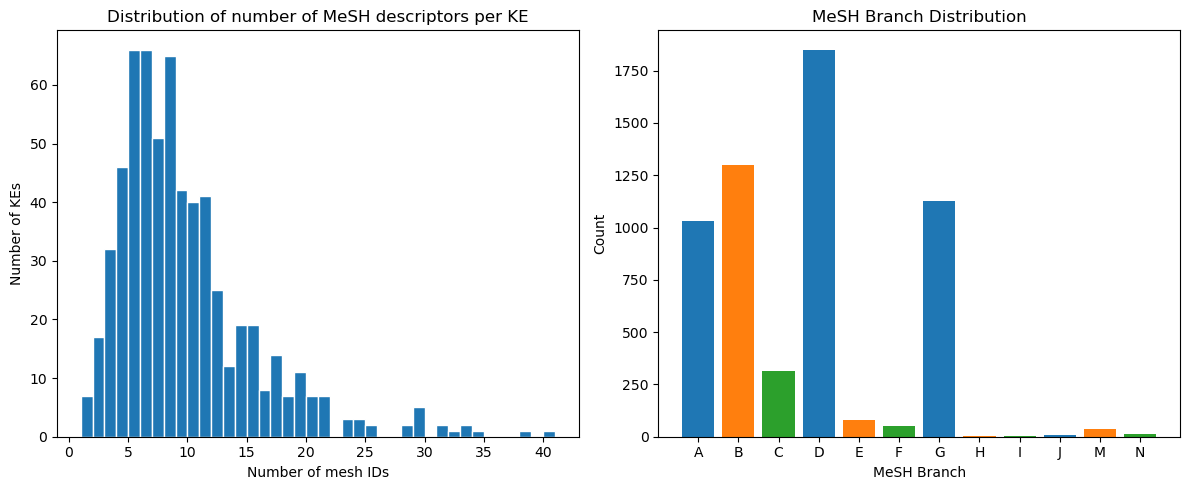

In [39]:
# Count the frequency of each MeSH thesaurus branch in the dataset
freq = Counter(indexing_results_dataframe["MESH_BRANCH"])
labels = sorted(freq.keys())
counts = [freq[k] for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left : histogram of the number of annotated MeSH per KE
axes[0].hist(num_mesh_per_ke, bins=range(1, num_mesh_per_ke.max()+2), edgecolor='white', color = "C0")
axes[0].set_title("Distribution of number of MeSH descriptors per KE")
axes[0].set_xlabel("Number of mesh IDs")
axes[0].set_ylabel("Number of KEs")

# Right : bar chart of MeSH thesaurus branch frequencies
axes[1].bar(labels, counts, color=["C0", "C1", "C2"])
axes[1].set_xlabel("MeSH Branch")
axes[1].set_ylabel("Count")
axes[1].set_title("MeSH Branch Distribution")

plt.tight_layout()
plt.show()

- The distribution of the number of MeSH descriptors per KE appears roughly normal, with most KEs having between 5 and 10 associated MeSH descriptors, suggesting a balanced annotation process by the indexer.     
- The thesaurus branch D (*Chemicals and Drugs*), B (*Organsims*), G (*Phenomena and Processes*), and A (*Anatomy*) are the most frequent, with some changes in proportion compared to the most represented branches in the complete set of active MeSH descriptors. The dominance of these branches indicates a focus on diseases, organisms, and biological processes in the dataset.

In [40]:
# Get the set of all unique MeSH thesaurus branches in the dataset.
all_branches = set(MeSH_branches["MESH_BRANCH"].unique())

# Get the set of MeSH branches actually present in the indexing results.
used_branches = set(indexing_results_dataframe["MESH_BRANCH"].unique())

# Identify branches that are not present in the indexing results. 
empty_branches = all_branches - used_branches
print(empty_branches)

{'L', 'K'}


Branches K (*Humanities*) and L (*Information Science*) are not present in teh indexing results dataset. We'll need to remove them for the manual matching of KEs lacking a publicly available description.

### Retrieve indexing scores for ALL pairs

In [50]:
def predict_long_text_with_logits(text, model, tokenizer, chunk_size=512, overlap=50):
    chunks = chunk_text(text, tokenizer, chunk_size, overlap)
    all_probs = []

    for chunk_ids in chunks:
        inputs = tokenizer.prepare_for_model(
            chunk_ids,
            padding="max_length",
            truncation=True,
            max_length=chunk_size,
            return_tensors="pt"
        )
        inputs = {k: v.unsqueeze(0) for k, v in inputs.items()}

        outputs = model(**inputs, return_labels=False)
        all_probs.append(outputs)

    stacked = torch.stack(all_probs, dim=0).squeeze(1)  # (num_chunks, num_labels)
    pooled  = stacked.max(dim=0).values                  # (num_labels,)

    # Return ALL labels with their scores, no threshold filtering
    predicted_labels = [
        {
            "MESH_TITLE": model.config.id2label[i],
            "SCORE":      round(pooled[i].item(), 4)
        }
        for i in range(len(pooled))  # <-- iterate over every label index
    ]

    predicted_labels.sort(key=lambda x: x["SCORE"], reverse=True)
    return predicted_labels

In [51]:
indexing_results_scores = []

# Set the model to evaluation mode : disables dropout and other training-specific layers
wellcomeBertMesh_model.eval()

# Disable gradient computation since we are doing inference only, not training. This reduces memory usage and speeds up the forward pass.
with torch.no_grad():
    for _, row in AOP_KEs_description.iterrows():
        id = row["KE_ID"]
        description = row["KE_DESCRIPTION"]

        # Tokenise the KE description with padding and truncation to the model's maximum input length
        inputs = wellcomeBertMesh_tokenizer(
            [description],
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Forward pass : return_labels = True triggers the model's built-in thresholding logic, returning predicted MeSH descriptor titles directly instead of raw logits
        labels = labels = predict_long_text_with_logits(
            description,
            wellcomeBertMesh_model,
            wellcomeBertMesh_tokenizer
        )

        indexing_results_scores.append({
            "KE_ID": id,
            "MESH_TITLES": labels
        })

In [52]:
rows = []
for result in indexing_results_scores:
    for label in result["MESH_TITLES"]:
        rows.append({
            "KE_ID":       result["KE_ID"],
            "MESH_TITLE":  label["MESH_TITLE"],
            "SCORE":       label["SCORE"]
        })

indexing_results_dataframe_scores = pd.DataFrame(rows)

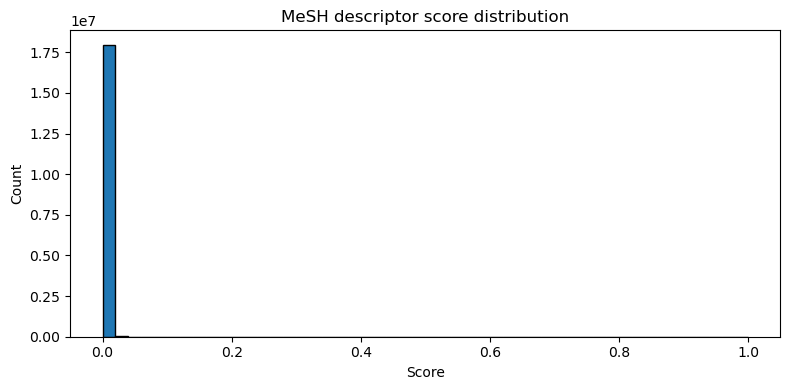

In [53]:
# Plot scores distribution
plt.figure(figsize=(8, 4))
plt.hist(indexing_results_dataframe_scores["SCORE"], bins=50, edgecolor="black")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("MeSH descriptor score distribution")
plt.tight_layout()
plt.show()

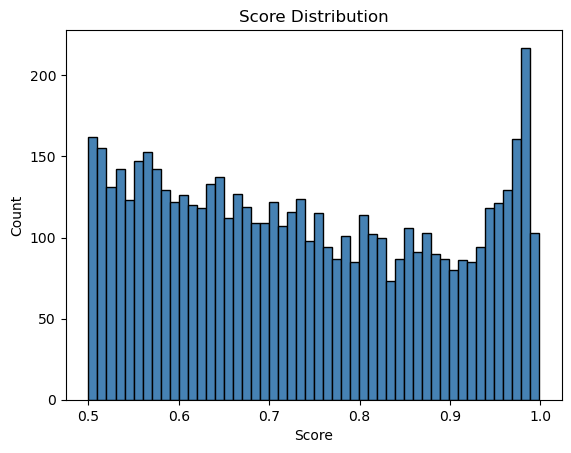

In [56]:
# Score distribution for pairs in basic indexing results
merged = indexing_results_dataframe_scores.merge(
    indexing_results_dataframe[["KE_ID", "MESH_TITLE"]],
    on = ["KE_ID", "MESH_TITLE"],
    how = "inner"
)

plt.hist(merged["SCORE"], bins = 50, edgecolor = "black", color = "steelblue")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Score Distribution")
plt.show()

In [161]:
stats = (
    indexing_results_dataframe_scores
    .groupby("KE_ID")["SCORE"]
    .agg(top_score="max", std="std", variance="var")
    .reset_index()
    .sort_values("top_score", ascending=False)
)

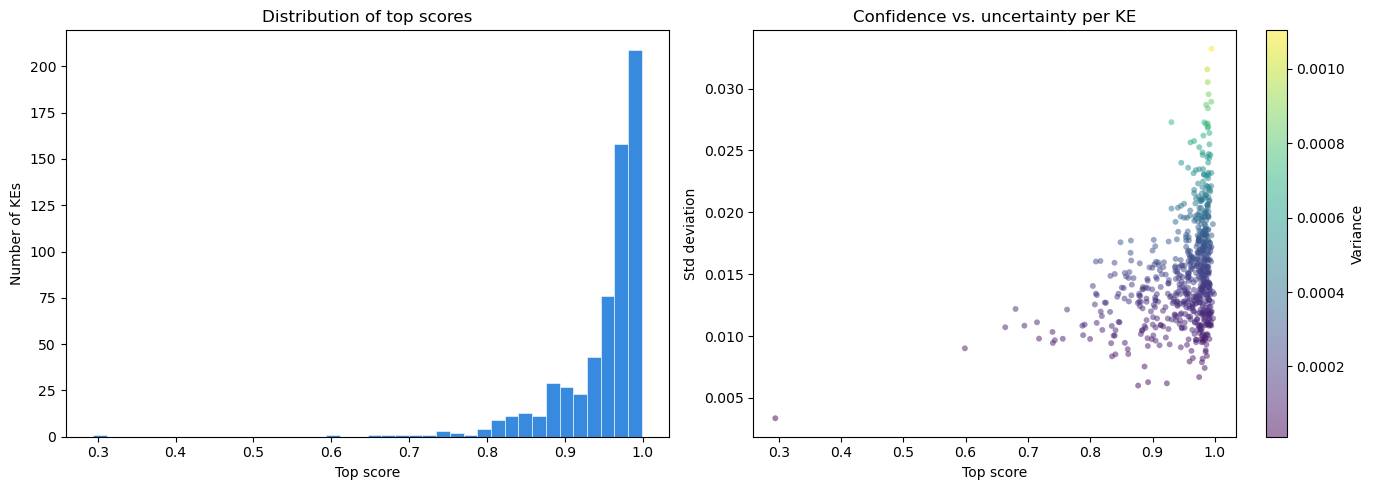

In [162]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: score distribution ---
ax1.hist(stats["top_score"], bins=40, color="#378ADD", edgecolor="white", linewidth=0.4)
ax1.set_xlabel("Top score")
ax1.set_ylabel("Number of KEs")
ax1.set_title("Distribution of top scores")

# --- Right: top score vs uncertainty scatter ---
sc = ax2.scatter(
    stats["top_score"],
    stats["std"].fillna(0),
    c=stats["variance"].fillna(0),
    cmap="viridis",
    alpha=0.5,
    s=18,
    linewidths=0
)
plt.colorbar(sc, ax=ax2, label="Variance")
ax2.set_xlabel("Top score")
ax2.set_ylabel("Std deviation")
ax2.set_title("Confidence vs. uncertainty per KE")

plt.tight_layout()
plt.show()

In [54]:
# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
indexing_results_dataframe_scores = MeSH_descriptors.merge(indexing_results_dataframe_scores, on = "MESH_TITLE")

# Merge with the MeSH branches dataframe to map each MESH_ID to the corresponding thesaurus branch
indexing_results_dataframe_scores = MeSH_branches.merge(indexing_results_dataframe_scores, on = "MESH_ID")

# Merge with the AOP KE dataframe to map each KE_TITLE to the corresponding KE_ID
indexing_results_dataframe_scores = AOP_KEs_description[["KE_ID", "KE_TITLE"]].merge(indexing_results_dataframe_scores, on = "KE_ID")

In [55]:
# Export indexing results with scores DF
indexing_results_dataframe_scores.to_csv("indexing_results_scores.tsv", sep = "\t", index = False)

In [167]:
# Get top 10 worst matches
top_per_ke = (
    indexing_results_dataframe_scores
    .sort_values("SCORE", ascending=False)
    .groupby("KE_ID", sort=False)
    .first()
    .reset_index()
)

worst_10 = (
    top_per_ke
    .nsmallest(10, "SCORE")[["KE_ID", "KE_TITLE", "MESH_TITLE", "SCORE"]]
    .reset_index(drop=True)
)

print(worst_10.to_string(index=False))

                                  KE_ID                                   KE_TITLE                       MESH_TITLE  SCORE
 https://identifiers.org/aop.events/749 Decreased, Progesterone from corpus luteum                           Humans 0.2943
 https://identifiers.org/aop.events/845                           Inhibition, UROD                           Humans 0.5987
https://identifiers.org/aop.events/2270  Increased, cholesterol synthesis enzymes                       Cholesterol 0.6635
https://identifiers.org/aop.events/2118         Succinate dehydrogenase, inhibited          Succinate Dehydrogenase 0.6801
https://identifiers.org/aop.events/1611                 Reduction, androstenedione 17-Hydroxysteroid Dehydrogenases 0.6943
https://identifiers.org/aop.events/1617                   Inhibition, 5α-reductase                     Testosterone 0.7145
 https://identifiers.org/aop.events/935                    KE2 : Decrease, GTPCH-1          Feedback, Physiological 0.7178
https://identifi

For Key Events (KEs) lacking publicly available descriptions, we need an alternative method to associate them with MeSH terms. Our first approach was to index only the KE titles.  

## 4. Indexing on Key Event titles

We performed indexing on KEs that do have a publicly available descriptions, from their titles only. This will allow us to compare the results with the previous indexing (which used descriptions), that we will consider from now on as ground truth for validation. 

### Basic indexing

In [57]:
indexing_results_titles = []

# Set the model to evaluation mode : disables dropout and other training-specific layers
wellcomeBertMesh_model.eval()

# Disable gradient computation since we are doing inference only, not training. This reduces memory usage and speeds up the forward pass.
with torch.no_grad():
    for _, row in AOP_KEs_description.iterrows():
        id = row["KE_ID"]
        description = row["KE_TITLE"]

        # Tokenise the KE description with padding and truncation to the model's maximum input length
        inputs = wellcomeBertMesh_tokenizer(
            [description],
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Forward pass : return_labels = True triggers the model's built-in thresholding logic, returning predicted MeSH descriptor titles directly instead of raw logits
        labels = wellcomeBertMesh_model(**inputs, return_labels=True)

        indexing_results_titles.append({
            "KE_ID": id,
            "MESH_TITLES": labels[0] # labels[0] is the list of predicted MeSH titles for this KE
        })

In [58]:
# Flatten the nested list into a list of dictionaries : one row per KE / MeSH pair.
indexing_results_flatten = []
for entry in indexing_results_titles :
    ke_id = entry["KE_ID"]
    for mesh in entry["MESH_TITLES"] :
        indexing_results_flatten.append({'KE_ID' : ke_id, 'MESH_TITLE' : mesh})

# Convert the flattened list into a DataFrame for easier manipulation and analysis
indexing_results_dataframe_titles = pd.DataFrame(indexing_results_flatten)

In [59]:
# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
indexing_results_dataframe_titles = MeSH_descriptors.merge(indexing_results_dataframe_titles, on = "MESH_TITLE")

# Merge with the MeSH branches dataframe to map each MESH_ID to the corresponding thesaurus branch
indexing_results_dataframe_titles = MeSH_branches.merge(indexing_results_dataframe_titles, on = "MESH_ID")

# Merge with the AOP KE dataframe to map each KE_TITLE to the corresponding KE_ID
indexing_results_dataframe_titles = AOP_KEs_description[["KE_ID", "KE_TITLE"]].merge(indexing_results_dataframe_titles, on = "KE_ID")

In [60]:
# Export indexing results with scores DF
indexing_results_dataframe_titles.to_csv("indexing_results_titles.tsv", sep = "\t", index = False)

In [61]:
# Create a baseline dictionary 
baseline = indexing_results_dataframe_titles.groupby("KE_ID")["MESH_ID"].apply(set)

# Calculate the number of unique MeSH IDs associated with each KE_ID.
num_mesh_per_ke = baseline.apply(len)

# Print summary statistics
print("Min number of mesh IDs per KE:", num_mesh_per_ke.min())
print("Max number of mesh IDs per KE:", num_mesh_per_ke.max())
print("Mean:", num_mesh_per_ke.mean())
print("Median:", num_mesh_per_ke.median())

Min number of mesh IDs per KE: 1
Max number of mesh IDs per KE: 8
Mean: 2.664
Median: 3.0


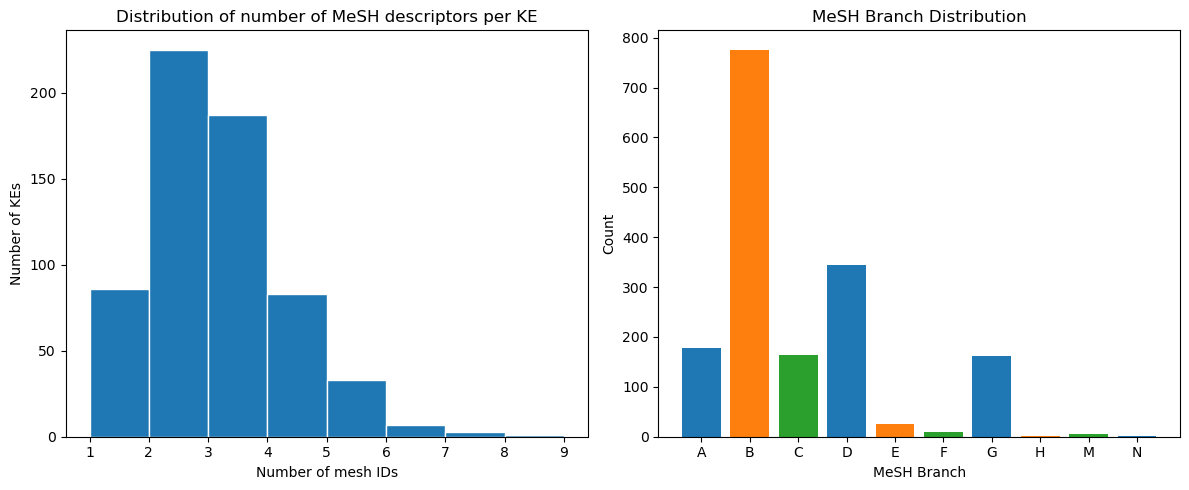

In [62]:
# Count the frequency of each MeSH thesaurus branch in the dataset
freq = Counter(indexing_results_dataframe_titles["MESH_BRANCH"])
labels = sorted(freq.keys())
counts = [freq[k] for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left : histogram of the number of annotated MeSH per KE
axes[0].hist(num_mesh_per_ke, bins=range(1, num_mesh_per_ke.max()+2), edgecolor='white', color = "C0")
axes[0].set_title("Distribution of number of MeSH descriptors per KE")
axes[0].set_xlabel("Number of mesh IDs")
axes[0].set_ylabel("Number of KEs")

# Right : bar chart of MeSH thesaurus branch frequencies
axes[1].bar(labels, counts, color=["C0", "C1", "C2"])
axes[1].set_xlabel("MeSH Branch")
axes[1].set_ylabel("Count")
axes[1].set_title("MeSH Branch Distribution")

plt.tight_layout()
plt.show()

The indexing on KE titles only associated less MeSH descriptors to each Key Event (median = 3 vs. median = 7 for indexing with descriptions). The most represented MeSH thesaurus branch is the branch B (Organisms), which is very different from the previous indexing results, and might no seem as informative regarding diseases or biological processes. 

### Retrieve indexing scores for all pairs KE - MeSh

In [64]:
indexing_results_titles_scores = []

# Set the model to evaluation mode : disables dropout and other training-specific layers
wellcomeBertMesh_model.eval()

# Disable gradient computation since we are doing inference only, not training. This reduces memory usage and speeds up the forward pass.
with torch.no_grad():
    for _, row in AOP_KEs_description.iterrows():
        id = row["KE_ID"]
        title = row["KE_TITLE"]

        # Tokenise the KE description with padding and truncation to the model's maximum input length
        inputs = wellcomeBertMesh_tokenizer(
            [title],
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Forward pass : return_labels = True triggers the model's built-in thresholding logic, returning predicted MeSH descriptor titles directly instead of raw logits
        labels = labels = predict_long_text_with_logits(
            title,
            wellcomeBertMesh_model,
            wellcomeBertMesh_tokenizer
        )

        indexing_results_titles_scores.append({
            "KE_ID": id,
            "MESH_TITLES": labels
        })

In [65]:
rows = []
for result in indexing_results_titles_scores:
    for label in result["MESH_TITLES"]:
        rows.append({
            "KE_ID":       result["KE_ID"],
            "MESH_TITLE":  label["MESH_TITLE"],
            "SCORE":       label["SCORE"]
        })

indexing_results_dataframe_titles_scores = pd.DataFrame(rows)

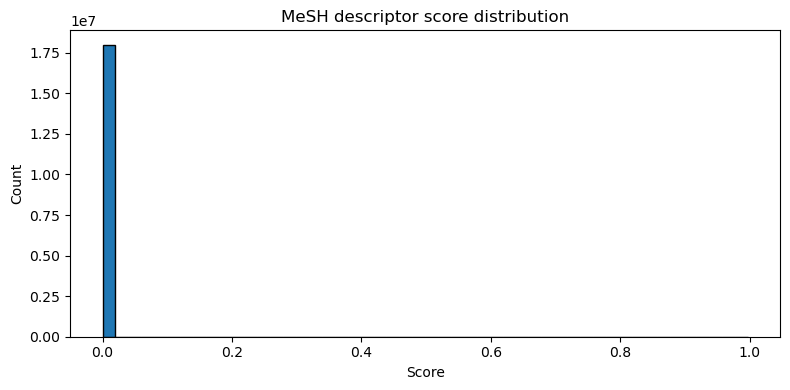

In [66]:
# Plot scores distribution
plt.figure(figsize=(8, 4))
plt.hist(indexing_results_dataframe_titles_scores["SCORE"], bins=50, edgecolor="black")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("MeSH descriptor score distribution")
plt.tight_layout()
plt.show()

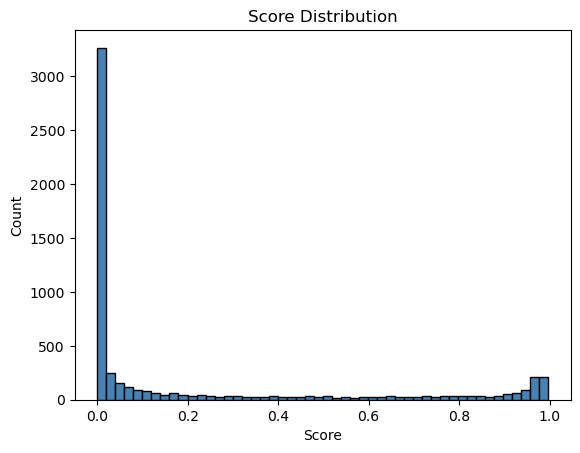

In [67]:
# Score distribution for pairs in basic indexing results
merged = indexing_results_dataframe_titles_scores.merge(
    indexing_results_dataframe[["KE_ID", "MESH_TITLE"]],
    on = ["KE_ID", "MESH_TITLE"],
    how = "inner"
)

plt.hist(merged["SCORE"], bins = 50, edgecolor = "black", color = "steelblue")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Score Distribution")
plt.show()

In [163]:
stats = (
    indexing_results_dataframe_titles_scores
    .groupby("KE_ID")["SCORE"]
    .agg(top_score="max", std="std", variance="var")
    .reset_index()
    .sort_values("top_score", ascending=False)
)

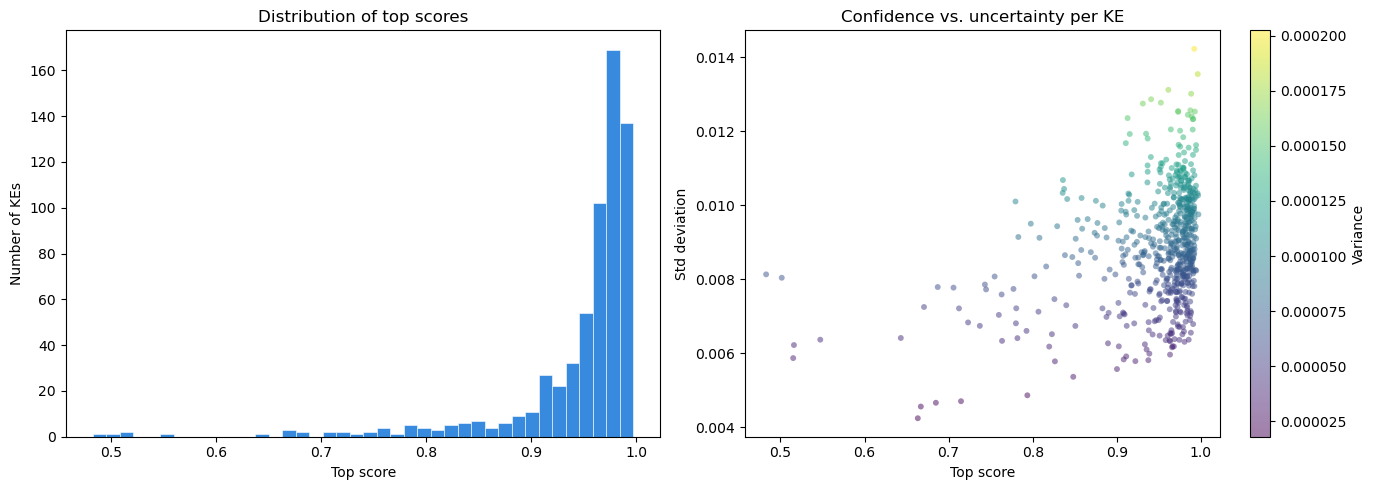

In [164]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: score distribution ---
ax1.hist(stats["top_score"], bins=40, color="#378ADD", edgecolor="white", linewidth=0.4)
ax1.set_xlabel("Top score")
ax1.set_ylabel("Number of KEs")
ax1.set_title("Distribution of top scores")

# --- Right: top score vs uncertainty scatter ---
sc = ax2.scatter(
    stats["top_score"],
    stats["std"].fillna(0),
    c=stats["variance"].fillna(0),
    cmap="viridis",
    alpha=0.5,
    s=18,
    linewidths=0
)
plt.colorbar(sc, ax=ax2, label="Variance")
ax2.set_xlabel("Top score")
ax2.set_ylabel("Std deviation")
ax2.set_title("Confidence vs. uncertainty per KE")

plt.tight_layout()
plt.show()

In [68]:
# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
indexing_results_dataframe_titles_scores = MeSH_descriptors.merge(indexing_results_dataframe_titles_scores, on = "MESH_TITLE")

# Merge with the MeSH branches dataframe to map each MESH_ID to the corresponding thesaurus branch
indexing_results_dataframe_titles_scores = MeSH_branches.merge(indexing_results_dataframe_titles_scores, on = "MESH_ID")

# Merge with the AOP KE dataframe to map each KE_TITLE to the corresponding KE_ID
indexing_results_dataframe_titles_scores = AOP_KEs_description[["KE_ID", "KE_TITLE"]].merge(indexing_results_dataframe_titles_scores, on = "KE_ID")

In [69]:
# Export indexing results with scores DF
indexing_results_dataframe_titles_scores.to_csv("indexing_results_titles_scores.tsv", sep = "\t", index = False)

In [168]:
# Get top 10 worst matches
top_per_ke = (
    indexing_results_dataframe_titles_scores
    .sort_values("SCORE", ascending=False)
    .groupby("KE_ID", sort=False)
    .first()
    .reset_index()
)

worst_10 = (
    top_per_ke
    .nsmallest(10, "SCORE")[["KE_ID", "KE_TITLE", "MESH_TITLE", "SCORE"]]
    .reset_index(drop=True)
)

print(worst_10.to_string(index=False))

                                  KE_ID                                                         KE_TITLE          MESH_TITLE  SCORE
 https://identifiers.org/aop.events/888 Binding of inhibitor, NADH-ubiquinone oxidoreductase (complex I)          Ubiquinone 0.4829
 https://identifiers.org/aop.events/887          Inhibition, NADH-ubiquinone oxidoreductase  (complex I)          Ubiquinone 0.5015
https://identifiers.org/aop.events/1509                                         Protein Adduct Formation            Proteins 0.5151
 https://identifiers.org/aop.events/981                           Reduction, NFAT/AP-1 complex formation Oxidation-Reduction 0.5160
https://identifiers.org/aop.events/1605                               Accumulation of misfolded proteins            Proteins 0.5473
https://identifiers.org/aop.events/1446                  Decrease, Coupling of oxidative phosphorylation     Phosphorylation 0.6431
 https://identifiers.org/aop.events/119                                     

### Evaluate performance compared to description-based indexing

In this section, we evaluated the performance of title-based indexing by comparing it to our ground truth (description-based indexing).  
  
**Methodology**:  
- True Positives (TP): MeSH-KE pairs identified in both title-based and description-based indexing.  
- False Positives (FP): MeSH-KE pairs identified in title-based indexing but missing in the ground truth.  
- False Negatives (FN): MeSH-KE pairs present in the ground truth, but missed in the title-based indexing.  
  
**Metrics**:  
- Precision: Measures the accuracy of title-based indexing (TP / (TP + FP))  
- Recall: Measures the coverage of title-based indexing (TP / (TP + FN))
- F1 Score: Harmonic mean of precision and recall, providing a balanced performance metric

In [70]:
def evaluation_metrics_no_score(baseline, results) :
    """
    Evaluate the performance of a MeSH indexing method by comparing it to a baseline (ground truth).

    This function calculates precision, recall, and F1 score for the predicted MeSH-KE pairs
    against a baseline dataset. It identifies True Positives (TP), False Positives (FP), and
    False Negatives (FN) to assess the accuracy and coverage of the indexing method.

    Parameters:
    -----------
    baseline : pandas.DataFrame
        The ground truth DataFrame containing columns "MESH_ID" and "KE_ID".
    results : pandas.DataFrame
        The DataFrame containing the predicted MeSH-KE pairs to evaluate, with columns "MESH_ID" and "KE_ID".

    Outputs:
    --------
    Prints the following metrics:
        - TP: Number of True Positives.
        - FP: Number of False Positives.
        - FN: Number of False Negatives.
        - Precision: Ratio of TP to (TP + FP).
        - Recall: Ratio of TP to (TP + FN).
        - F1 Score: Harmonic mean of precision and recall.
    """
    # Create sets of (MESH_ID, KE_ID) pairs for both ground truth (baseline) and results datasets.
    # This allows for efficient set operations to identify matches and mismatches.
    baseline_pairs = set(zip(baseline["MESH_ID"], baseline["KE_ID"]))
    result_pairs = set(zip(results["MESH_ID"], results["KE_ID"]))
    

    # Compute the confusion matrix components : 
    # - True Positive (TP) : pairs present in both baseline and results.
    # - False Positives (FP) :  pairs present in results but not in baseline
    # - False Negatives (FN) : pairs present in baseline but not in results
    tp = len(result_pairs & baseline_pairs)
    fp = len(result_pairs - baseline_pairs)
    fn = len(baseline_pairs - result_pairs)
    
    # Prepare lists for precision, recall, and F1 score calculation.
    # y_true = ground truth labels (1 for TP and FN, 0 for FP)
    # y_pred = predicted labels (1 for TP and FP, 0 for FN)
    y_true = [1]*tp + [0]*fp + [1]*fn
    y_pred = [1]*tp + [1]*fp + [0]*fn
    
    # Calculate precision, recall, and F1 score using sklearn.metrics.
    precision = metrics.precision_score(y_true, y_pred)
    recall = metrics.recall_score(y_true, y_pred)
    f1 = metrics.f1_score(y_true, y_pred)
    
    # Print the results
    print(f"TP: {tp}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")

In [71]:
# Evaluate the title-based indexing results against the ground truth (description-based indexing)
evaluation_metrics_no_score(indexing_results_dataframe, indexing_results_dataframe_titles)

TP: 1187
FP: 478
FN: 4625
Precision: 0.713
Recall: 0.204
F1 Score: 0.318


- The title-based indexing:  
- correctly identified 1,102 MeSH-KE pairs that were also identified by the description-based indexing,  
- incorrectly assigned 563 MeSH-KE pairs that were not present in the baseline,  
- missed 3,101 MeSH-KE pairs that were present in the baseline.  
This suggests some over-indexing or noise and a significant under-coverage when relying solely on title.  
  
0.662 precision means that 66.2% of the MeSh-KE pairs predicted by the title-based indexing were correct, when the model predicts a MeSH term for a KE, it is correct 66.2% of times.  
0.262 recall means that the title-based indexing only captured 26.2% of the MeSH-KE pairs, indicating that most relevant MeSH terms are missed when using titles alone.
A F1 score of 0.376 indicates that the low recall is dragging down the overall performance.

### Performance with scores

In [174]:
def rbo(list1, list2, p=0.9):
    score, weight = 0.0, 1.0
    for depth in range(1, min(len(list1), len(list2)) + 1):
        set1, set2 = set(list1[:depth]), set(list2[:depth])
        overlap = len(set1 & set2) / depth
        score += weight * overlap
        weight *= p
    return (1 - p) * score

In [175]:
gt_grouped_descriptions   = indexing_results_dataframe_scores.groupby("KE_ID")
pred_grouped_titles = indexing_results_dataframe_titles_scores.groupby("KE_ID")

common_ke_ids = [ke_id for ke_id in gt_grouped_descriptions.groups if ke_id in pred_grouped_titles.groups]

merged_all = []
for ke_id in common_ke_ids:
    gt   = gt_grouped_descriptions.get_group(ke_id)
    pred = pred_grouped_titles.get_group(ke_id)
    m    = gt.merge(pred, on="MESH_ID", suffixes=("_gt", "_pred"))
    m["KE_ID"] = ke_id
    merged_all.append(m)

merged_all = pd.concat(merged_all, ignore_index=True)

In [176]:
# --- NDCG ---
ndcg_scores = []
for ke_id, g in merged_all.groupby("KE_ID"):
    ndcg_scores.append(metrics.ndcg_score(
        np.array([g["SCORE_gt"].tolist()]),
        np.array([g["SCORE_pred"].tolist()])
    ))
mean_ndcg = np.mean(ndcg_scores)
print(f"Mean NDCG          : {mean_ndcg:.4f}")

Mean NDCG          : 0.6764


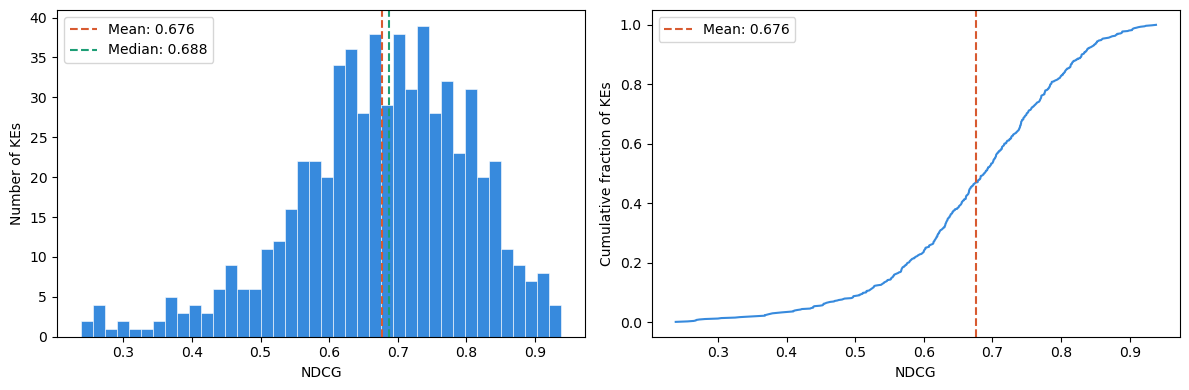

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram ---
axes[0].hist(ndcg_scores, bins=40, color="#378ADD", edgecolor="white", linewidth=0.4)
axes[0].axvline(mean_ndcg, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_ndcg:.3f}")
axes[0].axvline(np.median(ndcg_scores), color="#1D9E75", linewidth=1.5, linestyle="--", label=f"Median: {np.median(ndcg_scores):.3f}")
axes[0].set_xlabel("NDCG")
axes[0].set_ylabel("Number of KEs")
axes[0].legend()

# --- CDF ---
sorted_scores = np.sort(ndcg_scores)
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color="#378ADD", linewidth=1.5)
axes[1].axvline(mean_ndcg, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_ndcg:.3f}")
axes[1].set_xlabel("NDCG")
axes[1].set_ylabel("Cumulative fraction of KEs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Spearman ---
spearman_scores = merged_all.groupby("KE_ID").apply(
    lambda g: spearmanr(g["SCORE_gt"], g["SCORE_pred"])[0],
    include_groups=False
)
mean_spearman = spearman_scores.mean()
print(f"Mean Spearman      : {mean_spearman:.4f}")

Mean Spearman      : 0.4229


/tmp/ipykernel_11671/78290103.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spearman_scores = merged_all.groupby("KE_ID").apply(


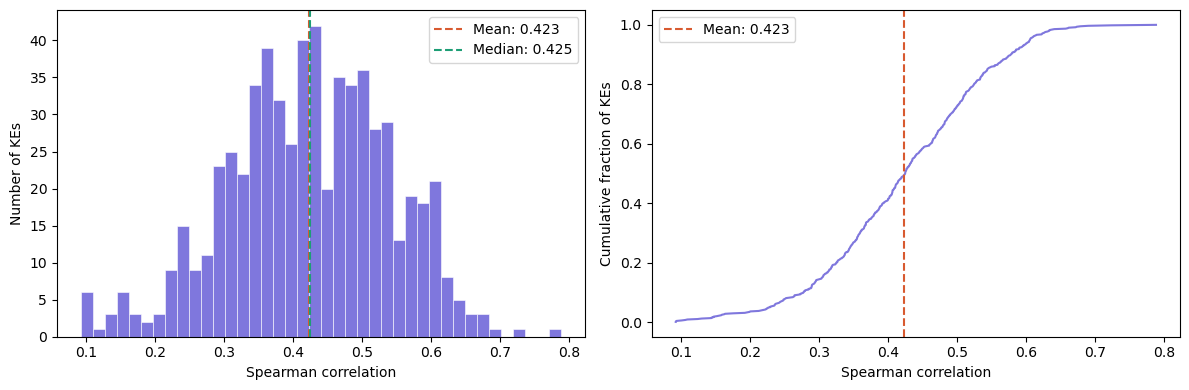

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram ---
axes[0].hist(spearman_scores, bins=40, color="#7F77DD", edgecolor="white", linewidth=0.4)
axes[0].axvline(mean_spearman, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_spearman:.3f}")
axes[0].axvline(spearman_scores.median(), color="#1D9E75", linewidth=1.5, linestyle="--", label=f"Median: {spearman_scores.median():.3f}")
axes[0].set_xlabel("Spearman correlation")
axes[0].set_ylabel("Number of KEs")
axes[0].legend()

# --- CDF ---
sorted_scores = np.sort(spearman_scores)
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color="#7F77DD", linewidth=1.5)
axes[1].axvline(mean_spearman, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_spearman:.3f}")
axes[1].set_xlabel("Spearman correlation")
axes[1].set_ylabel("Cumulative fraction of KEs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Kendall's tau ---
kendall_scores = merged_all.groupby("KE_ID").apply(
    lambda g: kendalltau(g["SCORE_gt"], g["SCORE_pred"])[0],
    include_groups=False
)
mean_kendall = kendall_scores.mean()
print(f"Mean Kendall's tau : {mean_kendall:.4f}")

Mean Kendall's tau : 0.4081


/tmp/ipykernel_11671/3251634730.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kendall_scores = merged_all.groupby("KE_ID").apply(


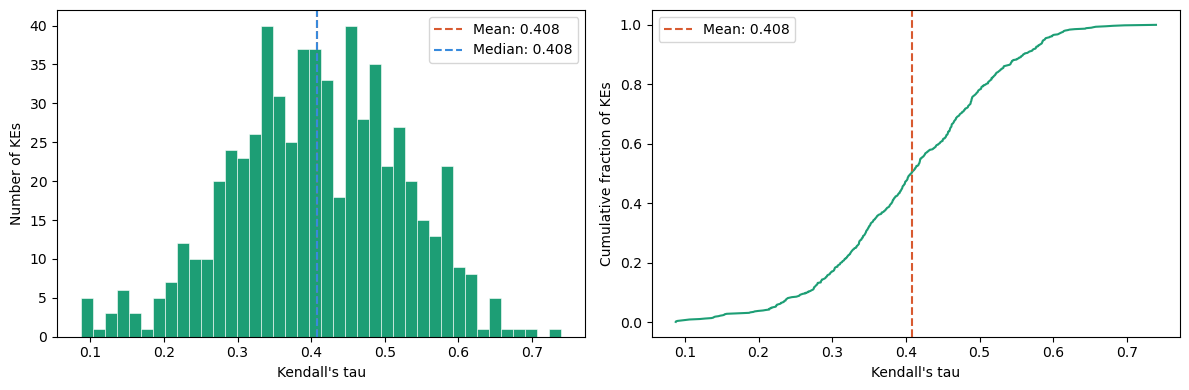

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram ---
axes[0].hist(kendall_scores, bins=40, color="#1D9E75", edgecolor="white", linewidth=0.4)
axes[0].axvline(mean_kendall, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_kendall:.3f}")
axes[0].axvline(kendall_scores.median(), color="#378ADD", linewidth=1.5, linestyle="--", label=f"Median: {kendall_scores.median():.3f}")
axes[0].set_xlabel("Kendall's tau")
axes[0].set_ylabel("Number of KEs")
axes[0].legend()

# --- CDF ---
sorted_scores = np.sort(kendall_scores)
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color="#1D9E75", linewidth=1.5)
axes[1].axvline(mean_kendall, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_kendall:.3f}")
axes[1].set_xlabel("Kendall's tau")
axes[1].set_ylabel("Cumulative fraction of KEs")
axes[1].legend()

plt.tight_layout()
plt.show()

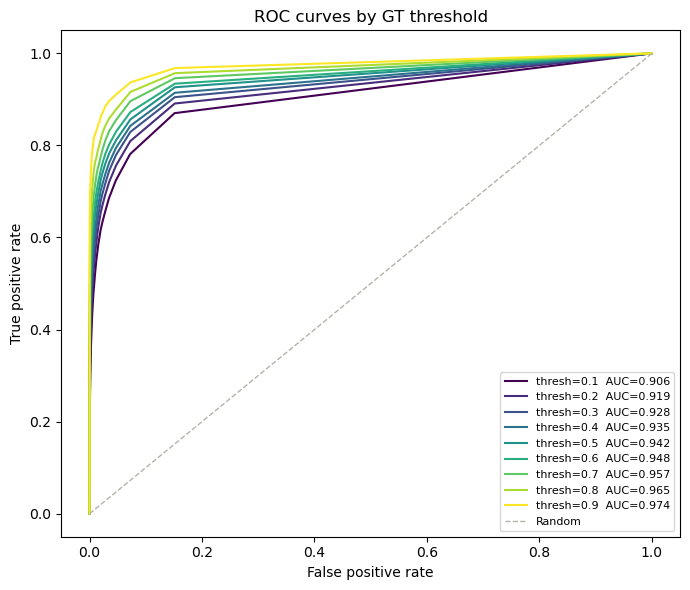

In [208]:
thresholds_to_plot = [round(t * 0.1, 1) for t in range(1, 10)]  # 0.1 to 0.9

fig, ax = plt.subplots(figsize=(7, 6))

cmap = plt.cm.viridis
colors = [cmap(i / (len(thresholds_to_plot) - 1)) for i in range(len(thresholds_to_plot))]

merged_base = indexing_results_dataframe_titles_scores.merge(
    indexing_results_dataframe_scores,
    on=["KE_ID", "MESH_TITLE"],
    suffixes=("_pred", "_gt")
)

for gt_threshold, color in zip(thresholds_to_plot, colors):
    merged = merged_base.copy()
    merged["relevant"] = (merged["SCORE_gt"] >= gt_threshold).astype(int)

    # Skip if only one class present
    if merged["relevant"].nunique() < 2:
        continue

    fpr, tpr, _ = metrics.roc_curve(merged["relevant"], merged["SCORE_pred"])
    roc_auc = metrics.auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=1.5, label=f"thresh={gt_threshold:.1f}  AUC={roc_auc:.3f}")

ax.plot([0, 1], [0, 1], color="#B4B2A9", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves by GT threshold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

In [200]:
def evaluate_at_n(gt_df, pred_df, top_n, rbo_p=0.9, gt_threshold=0.5):
    gt_grouped   = gt_df.groupby("KE_ID")
    pred_grouped = pred_df.groupby("KE_ID")

    common_ke_ids = [ke_id for ke_id in gt_grouped.groups if ke_id in pred_grouped.groups]

    # Build merged_all keeping only top_n per KE from each side
    merged_all = []
    for ke_id in common_ke_ids:
        gt   = gt_grouped.get_group(ke_id).nlargest(top_n, "SCORE")
        pred = pred_grouped.get_group(ke_id).nlargest(top_n, "SCORE")
        m    = gt.merge(pred, on="MESH_ID", suffixes=("_gt", "_pred"))
        m["KE_ID"] = ke_id
        merged_all.append(m)

    merged_all = pd.concat(merged_all, ignore_index=True)

    # --- Precision@N ---
    precision_scores = []
    jaccard_scores   = []
    for ke_id, g in merged_all.groupby("KE_ID"):
        gt_top   = set(gt_grouped.get_group(ke_id).nlargest(top_n, "SCORE")["MESH_ID"])
        pred_top = set(pred_grouped.get_group(ke_id).nlargest(top_n, "SCORE")["MESH_ID"])
        tp = len(gt_top & pred_top)
        precision_scores.append(tp / top_n)
        union = len(gt_top | pred_top)
        jaccard_scores.append(tp / union if union > 0 else 0)

    # --- NDCG ---
    ndcg_scores = []
    for ke_id, g in merged_all.groupby("KE_ID"):
        if len(g) < 2:
            continue
        ndcg_scores.append(metrics.ndcg_score(
            np.array([g["SCORE_gt"].tolist()]),
            np.array([g["SCORE_pred"].tolist()])
        ))

    # --- Spearman ---
    spearman_scores = merged_all.groupby("KE_ID").apply(
        lambda g: spearmanr(g["SCORE_gt"], g["SCORE_pred"])[0],
        include_groups=False
    )

    # --- Kendall's tau ---
    kendall_scores = merged_all.groupby("KE_ID").apply(
        lambda g: kendalltau(g["SCORE_gt"], g["SCORE_pred"])[0],
        include_groups=False
    )
    # --- RBO ---
    rbo_scores = []
    for ke_id, g in merged_all.groupby("KE_ID"):
        gt_ranked   = g.sort_values("SCORE_gt",   ascending=False)["MESH_ID"].tolist()
        pred_ranked = g.sort_values("SCORE_pred", ascending=False)["MESH_ID"].tolist()
        rbo_scores.append(rbo(pred_ranked, gt_ranked, p=rbo_p))

    # --- Print summary ---
    print(f"Evaluation @ top {top_n}")
    print(f"  Precision@{top_n}      : {np.mean(precision_scores):.4f}")
    print(f"  Jaccard@{top_n}        : {np.mean(jaccard_scores):.4f}")
    print(f"  Mean NDCG            : {np.mean(ndcg_scores):.4f}")
    print(f"  Mean Spearman        : {np.mean(spearman_scores):.4f}")
    print(f"  Mean Kendall's tau   : {np.mean(kendall_scores):.4f}")
    print(f"  Mean RBO (p={rbo_p}) : {np.mean(rbo_scores):.4f}")

    # --- ROC curve ---
    merged_all["relevant"] = (merged_all["SCORE_gt"] >= gt_threshold).astype(int)
    if merged_all["relevant"].nunique() > 1:
        fpr, tpr, _ = metrics.roc_curve(merged_all["relevant"], merged_all["SCORE_pred"])
        roc_auc     = metrics.auc(fpr, tpr)

        fig, ax = plt.subplots(figsize=(6, 6))

        ax.plot(fpr, tpr, color="#378ADD", linewidth=1.5, label=f"AUC = {roc_auc:.3f}")
        ax.plot([0, 1], [0, 1], color="#B4B2A9", linewidth=1, linestyle="--", label="Random")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title(f"ROC curve @ top {top_n}")
        ax.legend()

        plt.tight_layout()
        plt.show()
    else:
        print("  ROC skipped: only one class in relevant labels — try lowering gt_threshold")

    return {
        "precision":  np.mean(precision_scores),
        "jaccard":    np.mean(jaccard_scores),
        "ndcg":       np.mean(ndcg_scores),
        "spearman":   np.mean(spearman_scores),
        "kendall":    np.mean(kendall_scores),
        "rbo":        np.mean(rbo_scores),
    }

In [198]:
def plot_roc_curves(gt_df, pred_df, top_n, rbo_p=0.9):
    gt_grouped   = gt_df.groupby("KE_ID")
    pred_grouped = pred_df.groupby("KE_ID")
    common_ke_ids = [ke_id for ke_id in gt_grouped.groups if ke_id in pred_grouped.groups]

    merged = []
    for ke_id in common_ke_ids:
        gt   = gt_grouped.get_group(ke_id).nlargest(top_n, "SCORE")
        pred = pred_grouped.get_group(ke_id).nlargest(top_n, "SCORE")
        m    = gt.merge(pred, on="MESH_ID", suffixes=("_gt", "_pred"))
        m["KE_ID"] = ke_id
        merged.append(m)
    merged = pd.concat(merged, ignore_index=True)

    thresholds = np.arange(0.1, 1.0, 0.1).round(1)
    colors     = ["#042C53", "#0C447C", "#185FA5", "#378ADD", "#85B7EB",
                  "#D85A30", "#993C1D", "#712B13", "#4A1B0C"]

    fig, ax = plt.subplots(figsize=(7, 7))

    for threshold, color in zip(thresholds, colors):
        merged["relevant"] = (merged["SCORE_gt"] >= threshold).astype(int)
        if merged["relevant"].nunique() < 2:
            print(f"Skipping threshold {threshold:.1f} — only one class")
            continue
        fpr, tpr, _ = metrics.roc_curve(merged["relevant"], merged["SCORE_pred"])
        roc_auc     = metrics.auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=1.5, label=f"thr={threshold:.1f} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], color="#B4B2A9", linewidth=1, linestyle="--", label="Random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC curves at varying thresholds @ top {top_n}")
    ax.legend(fontsize=9, loc="lower right")

    plt.tight_layout()
    plt.show()

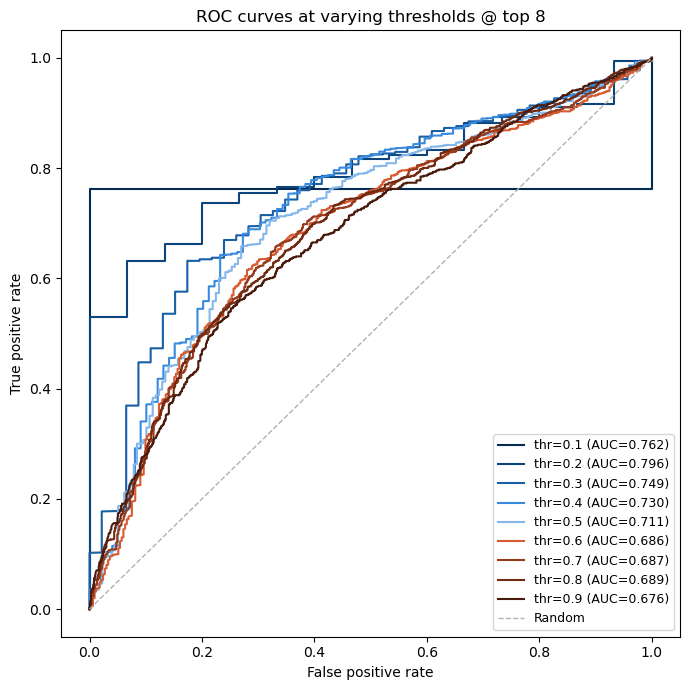

In [199]:
plot_roc_curves(
    gt_df   = indexing_results_dataframe_scores,
    pred_df = indexing_results_dataframe_titles_scores,
    top_n   = 8
)

Evaluation @ top 8
  Precision@8      : 0.3736
  Jaccard@8        : 0.2413
  Mean NDCG            : 0.9773
  Mean Spearman        : 0.3008
  Mean Kendall's tau   : 0.2715
  Mean RBO (p=0.9) : 0.1950


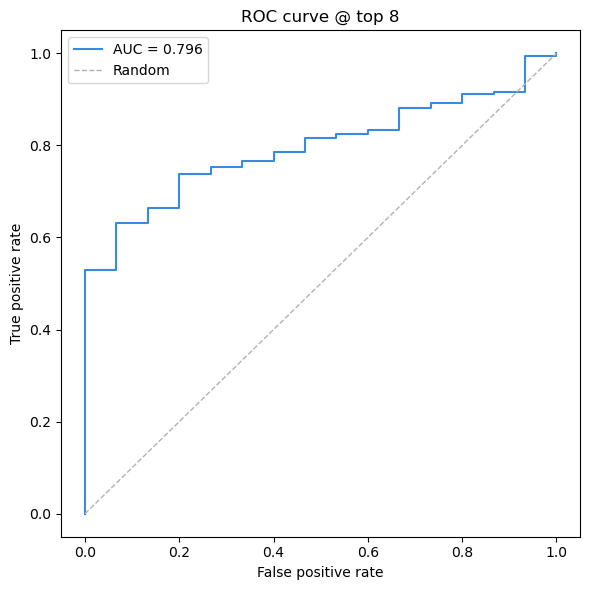

In [ ]:
results = evaluate_at_n(
    gt_df        = indexing_results_dataframe_scores,
    pred_df      = indexing_results_dataframe_titles_scores,
    top_n        = 8,
    rbo_p        = 0.9,
    gt_threshold = 0.2
)

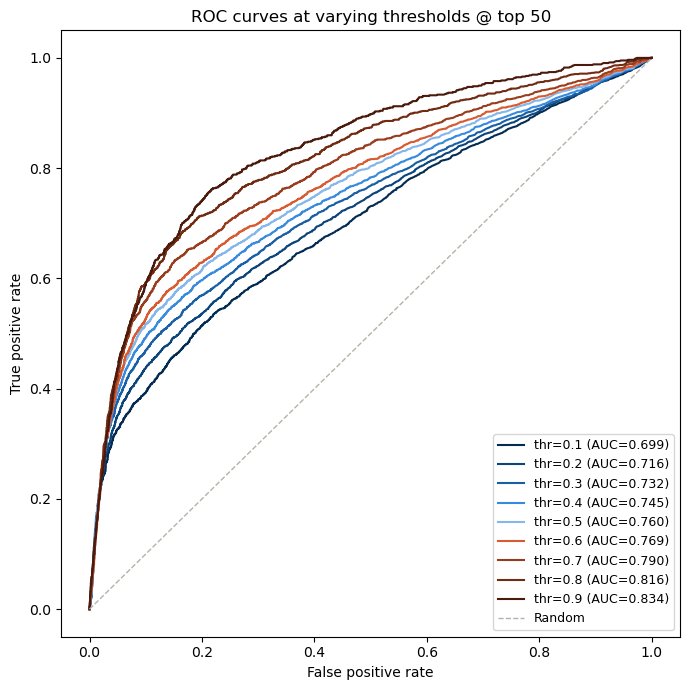

In [203]:
plot_roc_curves(
    gt_df   = indexing_results_dataframe_scores,
    pred_df = indexing_results_dataframe_titles_scores,
    top_n   = 50
)

Evaluation @ top 50
  Precision@50      : 0.2794
  Jaccard@50        : 0.1688
  Mean NDCG            : 0.9069
  Mean Spearman        : 0.4413
  Mean Kendall's tau   : 0.3263
  Mean RBO (p=0.9) : 0.4670


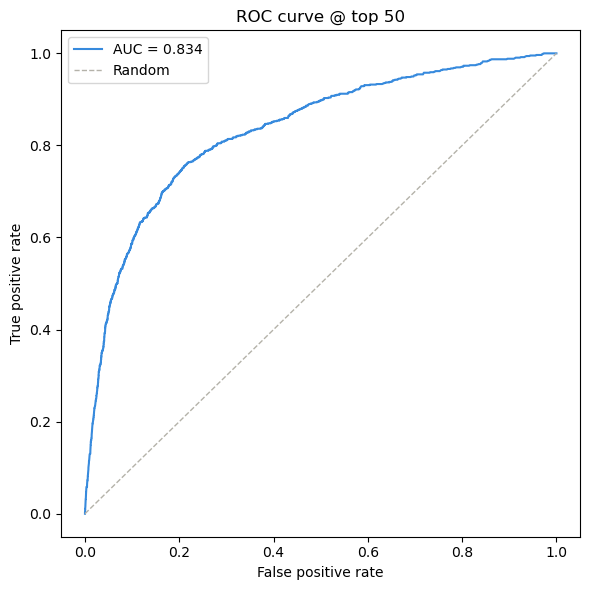

In [204]:
results = evaluate_at_n(
    gt_df        = indexing_results_dataframe_scores,
    pred_df      = indexing_results_dataframe_titles_scores,
    top_n        = 50,
    rbo_p        = 0.9,
    gt_threshold = 0.9
)

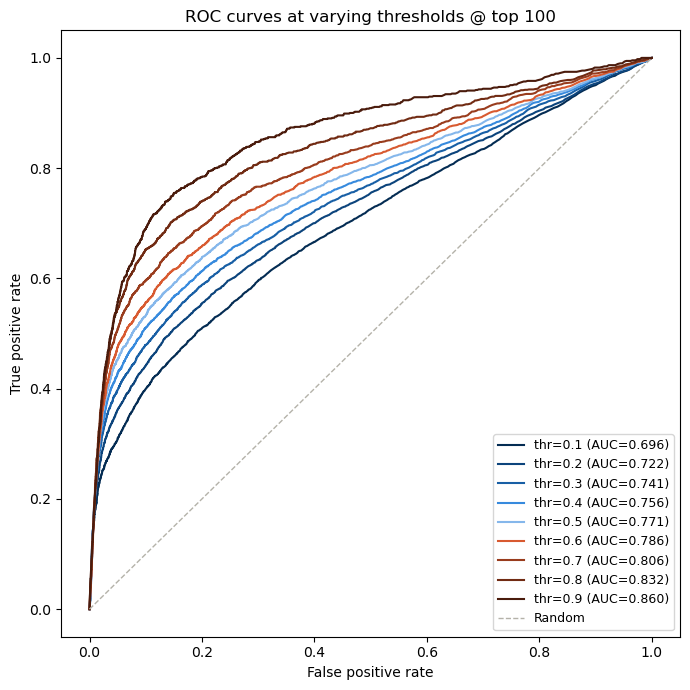

In [205]:
plot_roc_curves(
    gt_df   = indexing_results_dataframe_scores,
    pred_df = indexing_results_dataframe_titles_scores,
    top_n   = 100
)

Evaluation @ top 100
  Precision@100      : 0.2792
  Jaccard@100        : 0.1683
  Mean NDCG            : 0.8706
  Mean Spearman        : 0.4171
  Mean Kendall's tau   : 0.3019
  Mean RBO (p=0.9) : 0.5262


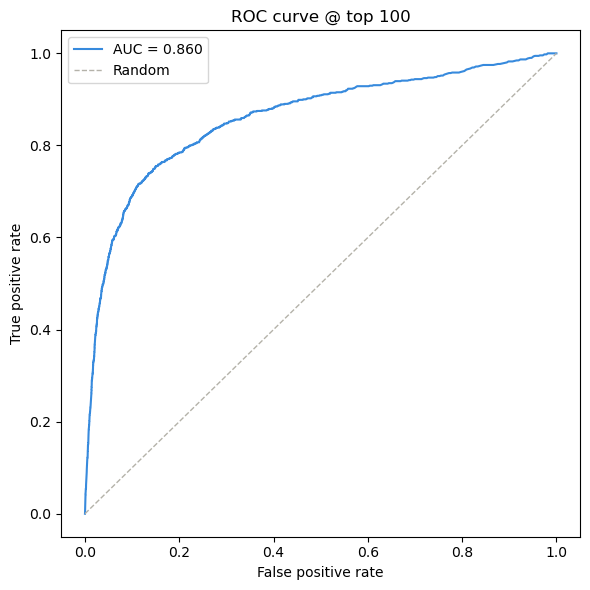

In [206]:
results = evaluate_at_n(
    gt_df        = indexing_results_dataframe_scores,
    pred_df      = indexing_results_dataframe_titles_scores,
    top_n        = 100,
    rbo_p        = 0.9,
    gt_threshold = 0.9
)

In the following sections, we will explore and test various approaches to improve the performance of KE - MeSH mapping.  

## 5. Fuzzy matching

Our first approach involves fuzzy string matching between MeSH descriptors and KE titles.  
- We used approximate string matching to identify potential similarities between MeSH descriptors and KE titles.  
- This serves as a preliminary step before applying more advanced semantic similarity methods. 

**Scope**: fuzzy matching is performedonly on KE titles. comparing MeSH titles to KE descriptions would be counter productive due to the significant difference in text length and the rich contextual information present in descriptions.

### Basic fuzzy matching

In [96]:
# Initialise an empty list to store the results of fuzzy matching
matches = []

# Iterate over each KE title
for ke_title in ke_titles_description :
    # For each KE, compare it with every MeSH descriptor title
    for mesh in MeSH_descriptors_titles :
        # Calculate the fuzzy match score (0-100) using Levenshtein distance
        # fuzz.ratio return a percentage indicating how similar the 2 strings are
        score = fuzz.ratio(mesh, ke_title)
        # Append the results as a dictionary to the matches list
        matches.append({
            "KE_TITLE": ke_title,
            "MESH_TITLE": mesh,
            "SCORE": score
        })

# Convert the list to a DataFrame for easier analysis and manipulation
results_fuzzy = pd.DataFrame(matches)

In [97]:
# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
results_fuzzy = MeSH_descriptors.merge(results_fuzzy, on = "MESH_TITLE")

# Merge with the MeSH branches dataframe to map each MESH_ID to the corresponding thesaurus branch
results_fuzzy = AOP_KEs_description.merge(results_fuzzy, on = "KE_TITLE")

# Reorder columns
results_fuzzy = results_fuzzy[["KE_ID", "KE_TITLE", "MESH_ID", "MESH_TITLE", "SCORE"]]

### Fuzzy matching with a score threshold

From the fuzzy matching results, we computed a score threshold to filter the results and retain only the top 20% of matches based on the similarity score.

In [98]:
# Calculate the threshold for the top 20% of similarity scores
threshold = np.percentile(results_fuzzy["SCORE"], 80)
print("Threshold for top 20% = ", threshold)

# Filte the DataFrame to keep only rows where the similarity score is greater than or equal to the threshold
fuzzy_top20 = results_fuzzy[results_fuzzy["SCORE"] >= threshold]

Threshold for top 20% =  32.432432432432435


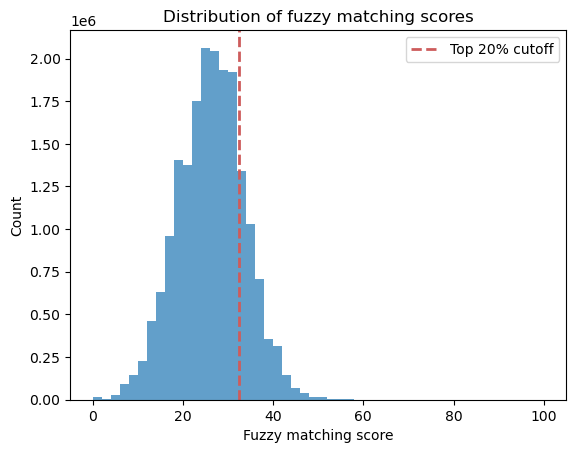

In [99]:
# Plot distribution of scores
results_fuzzy["SCORE"].hist(bins=50, alpha = 0.7, color = "C0")
plt.axvline(threshold, color='indianred', linestyle='--', linewidth=2, label='Top 20% cutoff')
plt.xlabel("Fuzzy matching score")
plt.ylabel("Count")
plt.title("Distribution of fuzzy matching scores")
plt.legend()
plt.grid(False)
plt.show()

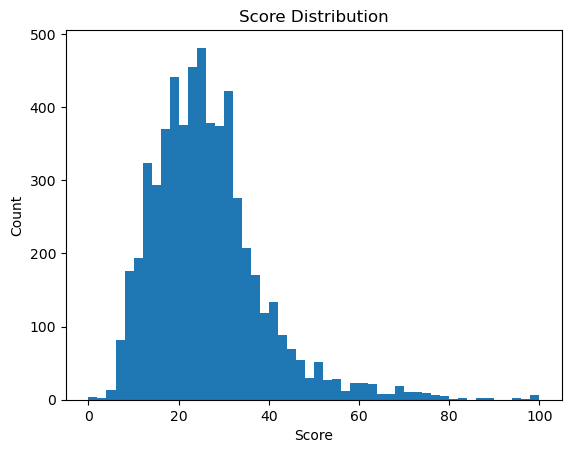

In [107]:
# Score distribution for pairs in basic indexing results
merged = results_fuzzy.merge(
    indexing_results_dataframe[["KE_ID", "MESH_TITLE"]],
    on = ["KE_ID", "MESH_TITLE"],
    how = "inner"
)

plt.hist(merged["SCORE"], bins = 50, color = "C0")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Score Distribution")
plt.show()

### Top 8 fuzzy matches

We showed that description-based indexing returned a median number of 7 MeSH descriptors per KE. Here, we select the top 7 fuzzy matches for each KE. 

In [105]:
# Sort the DataFrame by KE_ID and SCORE (descending)
results_fuzzy_sorted = results_fuzzy.sort_values(
    by=["KE_ID", "SCORE"],
    ascending=[True, False]
)

# Group by KE_ID and select the top 7 rows for each group
results_fuzzy_top8 = results_fuzzy_sorted.groupby("KE_ID").head(8)

# Reset the index for cleaner output
results_fuzzy_top8 = results_fuzzy_top8.reset_index(drop = True)

### Evaluate performance compared to description-based indexing

In [217]:
pred_grouped_fuzzy = results_fuzzy.groupby("KE_ID")

common_ke_ids = [ke_id for ke_id in gt_grouped_descriptions.groups if ke_id in pred_grouped_titles.groups]

merged_all = []
for ke_id in common_ke_ids:
    gt   = gt_grouped_descriptions.get_group(ke_id)
    pred = pred_grouped_fuzzy.get_group(ke_id)
    m    = gt.merge(pred, on="MESH_ID", suffixes=("_gt", "_pred"))
    m["KE_ID"] = ke_id
    merged_all.append(m)

merged_all = pd.concat(merged_all, ignore_index=True)

In [218]:
# --- NDCG ---
ndcg_scores = []
for ke_id, g in merged_all.groupby("KE_ID"):
    ndcg_scores.append(metrics.ndcg_score(
        np.array([g["SCORE_gt"].tolist()]),
        np.array([g["SCORE_pred"].tolist()])
    ))
mean_ndcg = np.mean(ndcg_scores)
print(f"Mean NDCG          : {mean_ndcg:.4f}")

Mean NDCG          : 0.2860


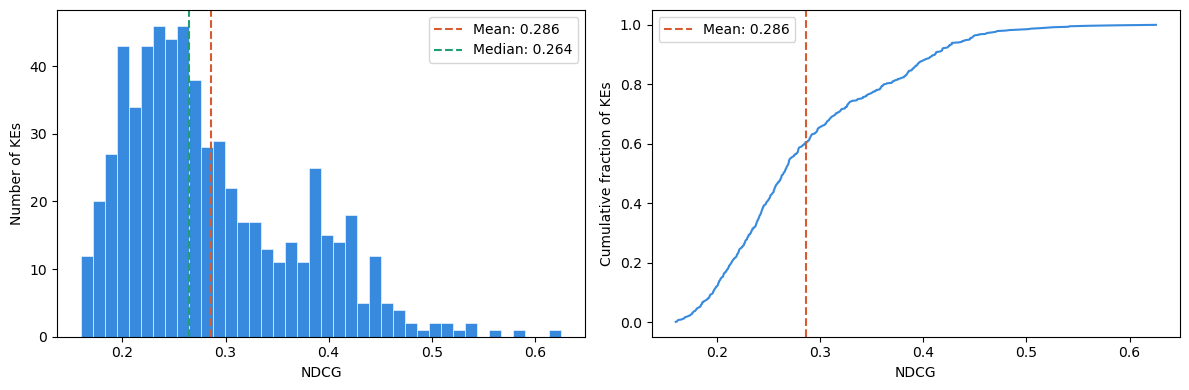

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram ---
axes[0].hist(ndcg_scores, bins=40, color="#378ADD", edgecolor="white", linewidth=0.4)
axes[0].axvline(mean_ndcg, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_ndcg:.3f}")
axes[0].axvline(np.median(ndcg_scores), color="#1D9E75", linewidth=1.5, linestyle="--", label=f"Median: {np.median(ndcg_scores):.3f}")
axes[0].set_xlabel("NDCG")
axes[0].set_ylabel("Number of KEs")
axes[0].legend()

# --- CDF ---
sorted_scores = np.sort(ndcg_scores)
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color="#378ADD", linewidth=1.5)
axes[1].axvline(mean_ndcg, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_ndcg:.3f}")
axes[1].set_xlabel("NDCG")
axes[1].set_ylabel("Cumulative fraction of KEs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [220]:
# --- Spearman ---
spearman_scores = merged_all.groupby("KE_ID").apply(
    lambda g: spearmanr(g["SCORE_gt"], g["SCORE_pred"])[0],
    include_groups=False
)
mean_spearman = spearman_scores.mean()
print(f"Mean Spearman      : {mean_spearman:.4f}")

Mean Spearman      : -0.0076


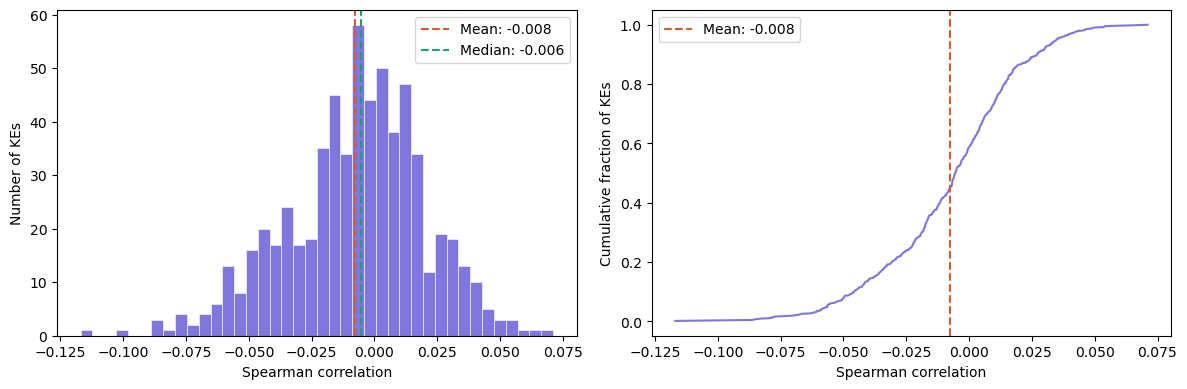

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram ---
axes[0].hist(spearman_scores, bins=40, color="#7F77DD", edgecolor="white", linewidth=0.4)
axes[0].axvline(mean_spearman, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_spearman:.3f}")
axes[0].axvline(spearman_scores.median(), color="#1D9E75", linewidth=1.5, linestyle="--", label=f"Median: {spearman_scores.median():.3f}")
axes[0].set_xlabel("Spearman correlation")
axes[0].set_ylabel("Number of KEs")
axes[0].legend()

# --- CDF ---
sorted_scores = np.sort(spearman_scores)
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color="#7F77DD", linewidth=1.5)
axes[1].axvline(mean_spearman, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_spearman:.3f}")
axes[1].set_xlabel("Spearman correlation")
axes[1].set_ylabel("Cumulative fraction of KEs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [222]:
# --- Kendall's tau ---
kendall_scores = merged_all.groupby("KE_ID").apply(
    lambda g: kendalltau(g["SCORE_gt"], g["SCORE_pred"])[0],
    include_groups=False
)
mean_kendall = kendall_scores.mean()
print(f"Mean Kendall's tau : {mean_kendall:.4f}")

Mean Kendall's tau : -0.0061


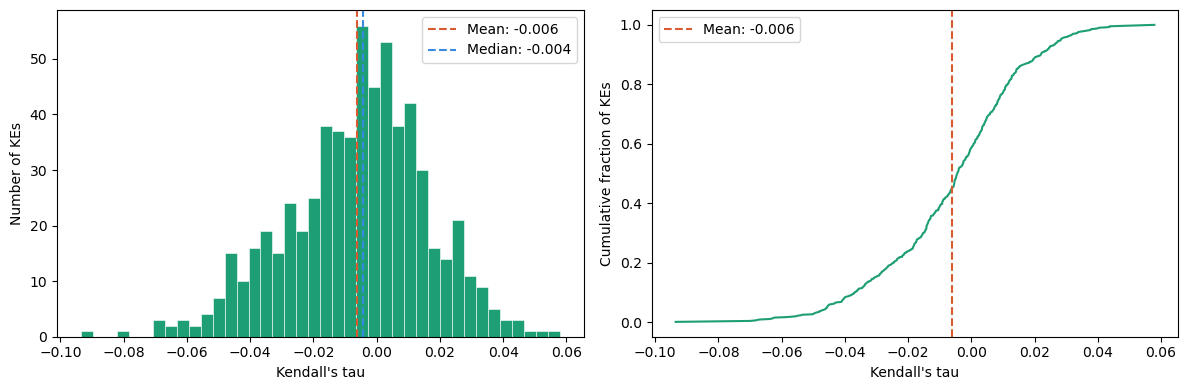

In [223]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram ---
axes[0].hist(kendall_scores, bins=40, color="#1D9E75", edgecolor="white", linewidth=0.4)
axes[0].axvline(mean_kendall, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_kendall:.3f}")
axes[0].axvline(kendall_scores.median(), color="#378ADD", linewidth=1.5, linestyle="--", label=f"Median: {kendall_scores.median():.3f}")
axes[0].set_xlabel("Kendall's tau")
axes[0].set_ylabel("Number of KEs")
axes[0].legend()

# --- CDF ---
sorted_scores = np.sort(kendall_scores)
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color="#1D9E75", linewidth=1.5)
axes[1].axvline(mean_kendall, color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean: {mean_kendall:.3f}")
axes[1].set_xlabel("Kendall's tau")
axes[1].set_ylabel("Cumulative fraction of KEs")
axes[1].legend()

plt.tight_layout()
plt.show()

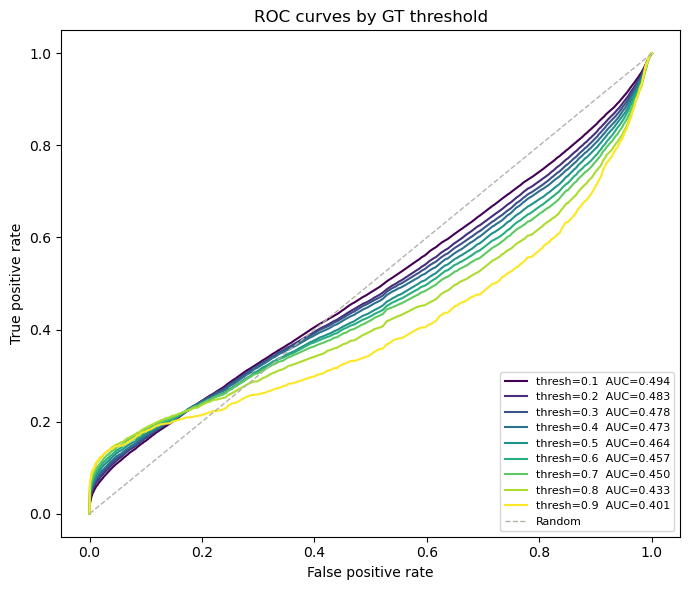

In [ ]:
thresholds_to_plot = [round(t * 0.1, 1) for t in range(1, 10)]  # 0.1 to 0.9

fig, ax = plt.subplots(figsize=(7, 6))

cmap = plt.cm.viridis
colors = [cmap(i / (len(thresholds_to_plot) - 1)) for i in range(len(thresholds_to_plot))]

merged_base = results_fuzzy.merge(
    indexing_results_dataframe_scores,
    on=["KE_ID", "MESH_TITLE"],
    suffixes=("_pred", "_gt")
    
)

for gt_threshold, color in zip(thresholds_to_plot, colors):
    merged = merged_base.copy()
    merged["relevant"] = (merged["SCORE_gt"] >= gt_threshold).astype(int)

    # Skip if only one class present
    if merged["relevant"].nunique() < 2:
        continue

    fpr, tpr, _ = metrics.roc_curve(merged["relevant"], merged["SCORE_pred"])
    roc_auc = metrics.auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=1.5, label=f"thresh={gt_threshold:.1f}  AUC={roc_auc:.3f}")

ax.plot([0, 1], [0, 1], color="#B4B2A9", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves by GT threshold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

Skipping threshold 0.1 — only one class
Skipping threshold 0.2 — only one class


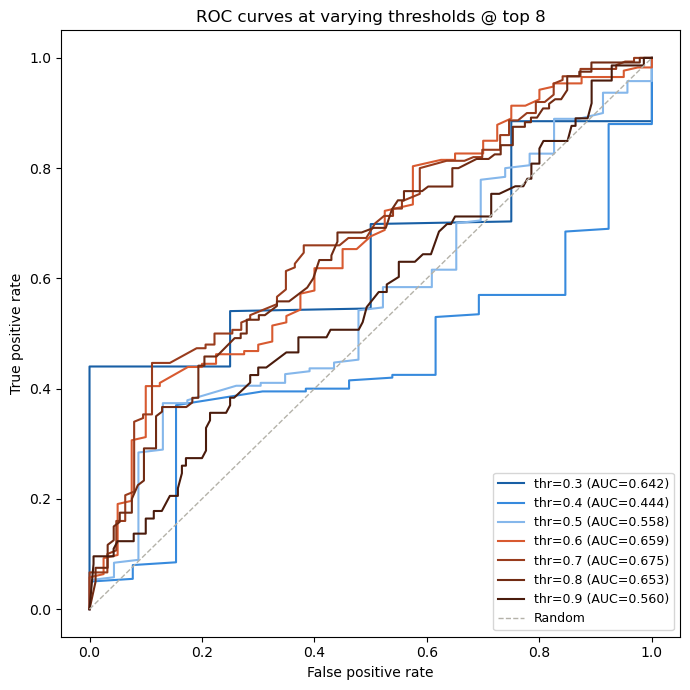

In [ ]:
plot_roc_curves(
    gt_df   = indexing_results_dataframe_scores,
    pred_df = results_fuzzy,
    top_n   = 8
)

/tmp/ipykernel_11671/1605603049.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda g: spearmanr(g["SCORE_gt"], g["SCORE_pred"])[0],


Evaluation @ top 8
  Precision@8      : 0.1487
  Jaccard@8        : 0.0816
  Mean NDCG            : 0.9639
  Mean Spearman        : -0.2385
  Mean Kendall's tau   : -0.2179
  Mean RBO (p=0.9) : 0.1061


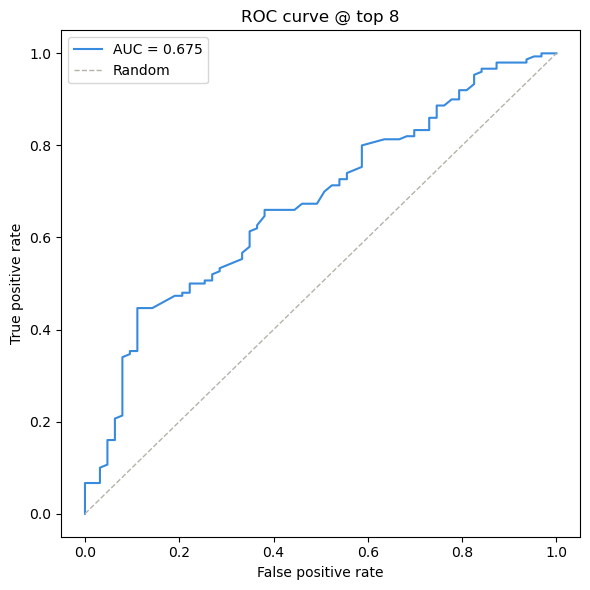

In [ ]:
results = evaluate_at_n(
    gt_df        = indexing_results_dataframe_scores,
    pred_df      = results_fuzzy,
    top_n        = 8,
    rbo_p        = 0.9,
    gt_threshold = 0.7
)

- The F1 score is extremely low, the method is failing to correclty identify most relevant MeSH-KE pairs.  
- A recall of 0.397 indicates that a majority of relevant pairs are missed.  
- The precition is very low, there is a high number of false positives, the method predicts many incorrect pairs.  
- The ROC-AUC is below 0.5, the method is performing worse than random guessing.   
  
This method is NOT effective and not reliable for our use case. This is expected since we didn't threshold the fuzzy matching results and kept all the matches.

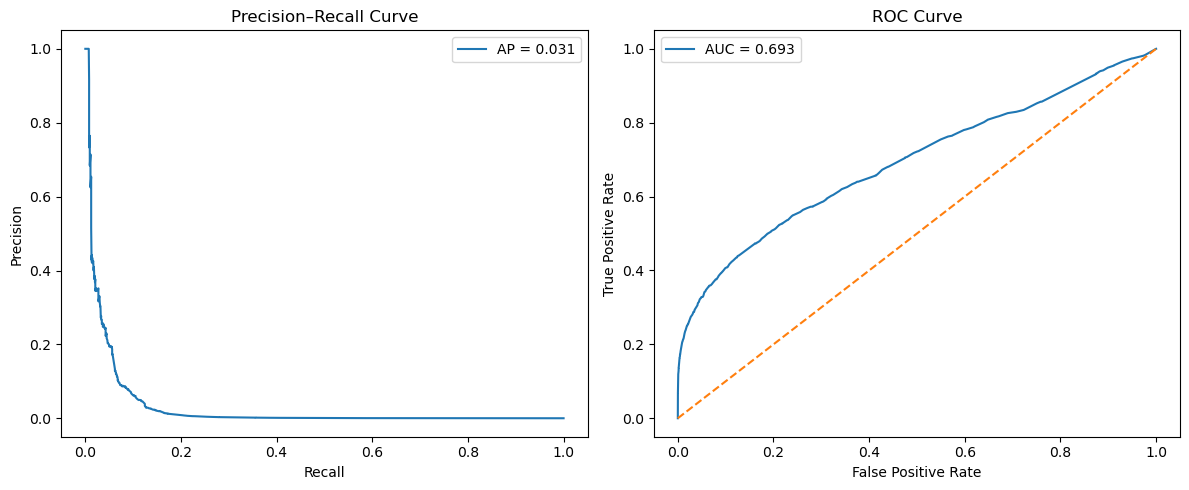

Average F1: 0.021
Average Recall: 0.369


In [104]:
evaluation_metrics(indexing_results_dataframe, fuzzy_top20)

After keeping the top 20% fuzzy matching results:  
- The F1 score is still very low, the method is still not effectively identifying relevant MeSh-KE pairs.  
- Recall has slightly improved.  
- Precision has improved from 0.010 to 0.037, but is still very low, there still is a lot of false positives.
- The ROC-AUC has significantly improved from 0.466 to 0.726, indicating that the method has moderate ability to distinguish between positive and negative pairs.

- The method catches most true positives (recall = 0.721) but it generates a lot of false postives (precision = 0.234). 
- The F1 score is still very low, probably dragged down by poor precision.     
- The ROC-AUC is still decent, meaning the model has reasonable discriminative ability overall.   
Overall, this approach is heavily turned towards recall, at the expense of precision.  
  
Given the not-so-good performance of fuzzy matching, we performed next semantic matching of KE titles and MeSH descriptors titles.   

## 6. Semantic matching

Semantic mathing matches elements based on their meaning or context, and is not just based on their exact form.    
We tested 5 models :    
- [allMiniLM](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2): lightweight general-domain model  
- [BioBERT](https://huggingface.co/pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb): pre-trained on PubMed abstracts and full-text articles 
- [SciBERT](https://huggingface.co/allenai/scibert_scivocab_uncased): pre-trained on broad scientific papers from Semantic Scholar
- [SapBERT](https://huggingface.co/cambridgeltl/SapBERT-from-PubMedBERT-fulltext): trained to align synonymous biomedical entities
- [BiomedBERT](https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract): pre-trained only on PubMed abstracts

In [108]:
def match_mesh_ke_title(mesh_descriptors, ke_titles, model):
    """
    Computes cosine similarity scores between MeSH descriptors and KE titles using sentence embeddings.

    Args:
        mesh_descriptors (list[str]): List of MeSH descriptor strings.
        ke_titles (list[str]): List of KE title strings.
        model (str): Name of the pretrained SentenceTransformer model to load.

    Returns:
        list[dict]: A list of dicts with keys:
            - "MESH_TITLE": the MeSH descriptor
            - "KE_TITLE": the compared KE title
            - "SCORE": cosine similarity score between the two
    """
    # Load the pretrained model
    model = SentenceTransformer(model)

    # Encode all KE titles into dense vectors
    ke_embeddings = model.encode(ke_titles, convert_to_tensor = True)

    results = []

    for mesh in mesh_descriptors :
        # Encode the current MeSh descriptor into a dense vector
        mesh_emb = model.encode(mesh, convert_to_tensor = True)
        
        # Compute cosine similarity between this MeSH embedding and all KE embeddings
        # cos_sim returns a 2D tensor, [0] selects the row of scores
        scores = util.cos_sim(mesh_emb, ke_embeddings)[0]

        # Store each (MeSH, KE) pair with its similarity score
        for id in range(len(ke_titles)):
            results.append({
                "MESH_TITLE" : mesh,
                "KE_TITLE" : ke_titles[id],
                "SCORE" : scores[id].item() # convert tensor scalar to Python float
            }) 
    return results

In [109]:
# all-MiniLM-L6-v2
results = match_mesh_ke_title(MeSH_descriptors_titles, ke_titles_description, model = "all-MiniLM-L6-v2")
res_KE_title_allMiniLM = pd.DataFrame(results)

In [110]:
# BioBERT
results = match_mesh_ke_title(MeSH_descriptors_titles, ke_titles_description, model = "pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")
res_KE_title_biobert = pd.DataFrame(results)

In [111]:
#SciBERT
results = match_mesh_ke_title(MeSH_descriptors_titles, ke_titles_description, model = "allenai/scibert_scivocab_uncased")
res_KE_title_scibert = pd.DataFrame(results)

No sentence-transformers model found with name /home/mmathe/.cache/torch/sentence_transformers/allenai_scibert_scivocab_uncased. Creating a new one with MEAN pooling.
Some weights of the model checkpoint at /home/mmathe/.cache/torch/sentence_transformers/allenai_scibert_scivocab_uncased were not used when initializing BertModel: ['cls.predictions.decoder.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly 

In [114]:
# SapBERT
results = match_mesh_ke_title(MeSH_descriptors_titles, ke_titles_description, model = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext")
res_KE_title_sapbert = pd.DataFrame(results)

No sentence-transformers model found with name /home/mmathe/.cache/torch/sentence_transformers/cambridgeltl_SapBERT-from-PubMedBERT-fulltext. Creating a new one with MEAN pooling.


In [115]:
# BiomedBERT
results = match_mesh_ke_title(MeSH_descriptors_titles, ke_titles_description, model = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract")
res_KE_title_biomedbert = pd.DataFrame(results)

No sentence-transformers model found with name /home/mmathe/.cache/torch/sentence_transformers/microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract. Creating a new one with MEAN pooling.
Some weights of the model checkpoint at /home/mmathe/.cache/torch/sentence_transformers/microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract were not used when initializing BertModel: ['cls.predictions.decoder.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint o

In [116]:
# Structure indexing results
# Tag each result dataframe with the name of the model that produced it
res_KE_title_allMiniLM['MODEL'] = "allMiniLM"
res_KE_title_biobert['MODEL'] = "biobert"
res_KE_title_scibert['MODEL'] = "scibert"
res_KE_title_sapbert['MODEL'] = "sapbert"
res_KE_title_biomedbert['MODEL'] = "biomedbert"

# Concatenate all per-model result dataframes into a single dataframe
# ignore_index = True resets the row index to avoid duplicate indices across sources
all_res_KE_title = pd.concat([
    res_KE_title_allMiniLM,
    res_KE_title_biobert,
    res_KE_title_scibert,
    res_KE_title_sapbert,
    res_KE_title_biomedbert
], ignore_index = True)

# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
all_res_KE_title = MeSH_descriptors.merge(all_res_KE_title, on = "MESH_TITLE")

# Merge with the MeSH branches dataframe to map each MESH_ID to the corresponding thesaurus branch
all_res_KE_title = AOP_KEs_description.merge(all_res_KE_title, on = "KE_TITLE")

# Reorder columns
all_res_KE_title = all_res_KE_title[["KE_ID", "KE_TITLE", "MESH_ID", "MESH_TITLE", "SCORE", "MODEL"]]

In [ ]:
# Export indexing results with scores DF
all_res_KE_title[all_res_KE_title["MODEL"] == "allMiniLM"].to_csv("semantic_matching_results_titles_allMiniLM.tsv", sep = "\t", index = False)
all_res_KE_title[all_res_KE_title["MODEL"] == "biobert"].to_csv("semantic_matching_results_titles_biobert.tsv", sep = "\t", index = False)
all_res_KE_title[all_res_KE_title["MODEL"] == "scibert"].to_csv("semantic_matching_results_titles_scibert.tsv", sep = "\t", index = False)
all_res_KE_title[all_res_KE_title["MODEL"] == "sapbert"].to_csv("semantic_matching_results_titles_sapbert.tsv", sep = "\t", index = False)
all_res_KE_title[all_res_KE_title["MODEL"] == "biomedbert"].to_csv("semantic_matching_results_titles_biomedbert.tsv", sep = "\t", index = False)

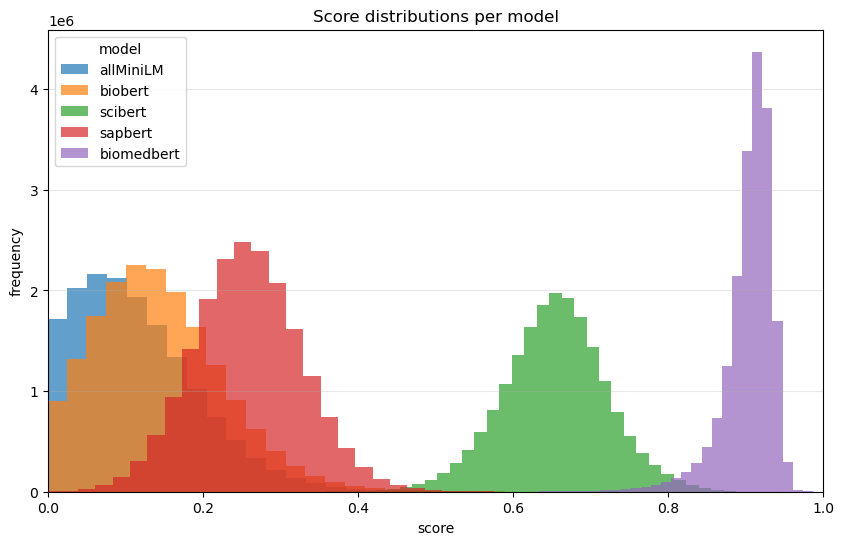

In [ ]:
# Plot score distributions for each model
plt.figure(figsize=(10, 6))

models = all_res_KE_title['MODEL'].unique()
colors = ['C0', 'C1', 'C2', 'C3', 'C4'] 

for i, model in enumerate(models):
    scores = all_res_KE_title[all_res_KE_title['MODEL'] == model]['SCORE']
    plt.hist(scores, bins = 50, alpha = 0.7, label = model, color = colors[i])

plt.title("Score distributions per model")
plt.xlabel("score")
plt.ylabel("frequency")
plt.xlim(0, 1)
plt.legend(title = "model")
plt.grid(axis = 'y', alpha = 0.3)
plt.show()

### Compare score rankings

In [121]:
evaluate_ranking(indexing_results_dataframe_scores, all_res_KE_title[all_res_KE_title["MODEL"] == "allMiniLM"])

Mean Precision@8 : 0.1278
Mean NDCG              : 0.4250
Mean Spearman          : 0.1249
Mean RBO               : 0.0719


In [122]:
evaluate_ranking(indexing_results_dataframe_scores, all_res_KE_title[all_res_KE_title["MODEL"] == "biobert"])

Mean Precision@8 : 0.1282
Mean NDCG              : 0.4173
Mean Spearman          : 0.1113
Mean RBO               : 0.0709


In [123]:
evaluate_ranking(indexing_results_dataframe_scores, all_res_KE_title[all_res_KE_title["MODEL"] == "scibert"])

Mean Precision@8 : 0.0290
Mean NDCG              : 0.2900
Mean Spearman          : 0.0944
Mean RBO               : 0.0151


In [124]:
evaluate_ranking(indexing_results_dataframe_scores, all_res_KE_title[all_res_KE_title["MODEL"] == "sapbert"])

Mean Precision@8 : 0.1306
Mean NDCG              : 0.4140
Mean Spearman          : 0.0483
Mean RBO               : 0.0733


In [125]:
evaluate_ranking(indexing_results_dataframe_scores, all_res_KE_title[all_res_KE_title["MODEL"] == "biomedbert"])

Mean Precision@8 : 0.0391
Mean NDCG              : 0.2911
Mean Spearman          : 0.0143
Mean RBO               : 0.0215


### Top 8 semantic matches

With the same logic as presented in the fuzzy matching part, we select the top 7 MeSH desriptors semantic matches, for each KE and for each model.

In [141]:
# For each model and KE, keep only the top 8 most similar MeSH descriptors
all_res_KE_title_top8 = (
    all_res_KE_title
    .sort_values("SCORE", ascending = False)
    .groupby(["MODEL", "KE_ID"])
    .head(8)
    .reset_index(drop = True)
)

### Evaluate performance compared to indexing on descriptions

In [142]:
def evaluation_metrics_models(baseline, results) :
    """
    Evaluates and compares multiple models by plotting Precision-Recall and ROC curves, and printing average F1 and Recall for each model.

    Args:
        baseline (pd.DataFrame): Reference dataframe of validated (MESH_ID, KE_ID) pairs,
                                 used as ground truth positives.
        results (pd.DataFrame):  Dataframe of candidate matches with columns
                                 MESH_ID, KE_ID, SCORE, and MODEL.
    """
    # Work on a copy to avoid mutating the original dataframe
    results = results.copy()

    # Assign a unique integer ID to each distinct (MESH_ID, KE_ID) pair
    results["pair_id"] = results.groupby(["MESH_ID", "KE_ID"]).ngroup()
    
    # Label each pair as positive (1) if it exists in the baseline, negative (0) otherwise
    results["true"] = (
        results.set_index(["MESH_ID", "KE_ID"]).index
        .isin(baseline.set_index(["MESH_ID", "KE_ID"]).index)
        .astype(int)
    )
    
    # Set up a side-by-side figure: Precision-Recall on the left, ROC on the right
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Evaluate each model
    for model_name, model_df in results.groupby("MODEL"):
        y_true = model_df["true"]
        y_scores = model_df["SCORE"]
        
        # Precision-Recall curve
        precision, recall, thresholds = metrics.precision_recall_curve(y_true, y_scores)
        ap = metrics.average_precision_score(y_true, y_scores)
        axes[0].plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")
        
        # ROC curve
        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
        auc = metrics.auc(fpr, tpr)
        axes[1].plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

        # Summary metrics
        f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
        f1 = np.mean(f1_scores)
        
        print(f"{model_name}")
        print(f"Average F1: {f1:.3f}")
        avg_recall = np.mean(recall)
        print(f"Average Recall: {avg_recall:.3f}")
        
    
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Precision–Recall Curve")
    axes[0].legend()

    axes[1].plot([0, 1], [0, 1], linestyle="--")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

allMiniLM
Average F1: 0.002
Average Recall: 0.750
biobert
Average F1: 0.002
Average Recall: 0.722
biomedbert
Average F1: 0.001
Average Recall: 0.647
sapbert
Average F1: 0.002
Average Recall: 0.731
scibert
Average F1: 0.001
Average Recall: 0.628


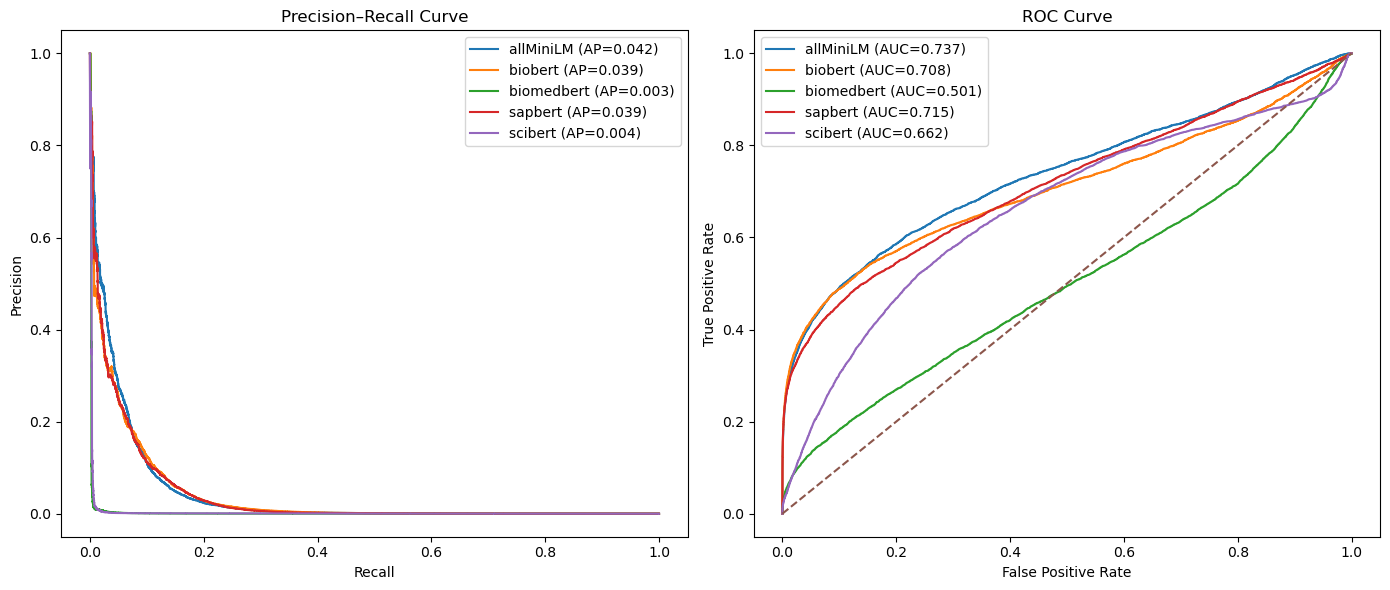

In [143]:
evaluation_metrics_models(indexing_results_dataframe, all_res_KE_title)

Despite being a general-purpose model, allMiniLM seems to outperform the biomedical-specific models (except sapbert).   
We didn't select top matches, so as expected, all models share a very low F1, dragged down by a very low precision.  

allMiniLM
Average F1: 0.295
Average Recall: 0.705
biobert
Average F1: 0.288
Average Recall: 0.690
biomedbert
Average F1: 0.099
Average Recall: 0.583
sapbert
Average F1: 0.280
Average Recall: 0.656
scibert
Average F1: 0.085
Average Recall: 0.648


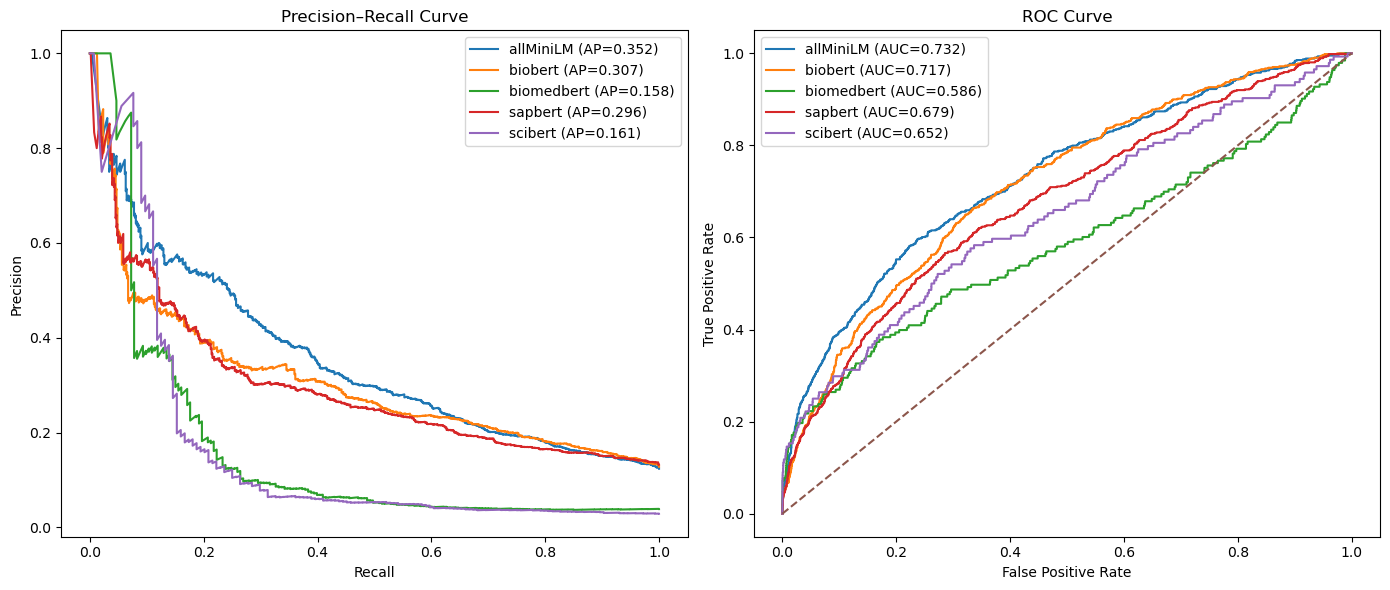

In [129]:
evaluation_metrics_models(indexing_results_dataframe, all_res_KE_title_top8)

By selecting the top 7 MeSH descriptors matches for each KE, we have significantly better results.   
- allMiniLM is the top performer across all metrics, and the grap over biomedical-domain model is even more clear.  
- BioBERT and SapBERT seem to be quite competitive. This is a bit surprising given SapBERT's entity-matching pretraining, but suggests it might be less robust for matching non strictly biomedical entities (chemicals).  
- BiomedBERT and SciBERT struggle on this task.

## 7. Part Of Speech tagging

The Part Of Speech tagging process assigns grammatical categories (verb, noun, adjective, ...) to each token in a text based on its definition and context.  
Here, we separate KE titles into noun phrases before performing semantic matching with MeSH descriptors.

### Stop words

In [130]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_most_frequent_words(ke_titles, top_n=20):
    all_words = []
    
    for title in ke_titles:
        # Tokenize and lowercase
        tokens = nltk.word_tokenize(title.lower())
        
        # Keep only alphabetic tokens and remove stopwords
        filtered = [t for t in tokens if t.isalpha() and t not in stop_words]
        
        all_words.extend(filtered)
    
    # Count and return the top_n most frequent words
    counter = Counter(all_words)
    return counter.most_common(top_n)

# Usage
frequent_words = get_most_frequent_words(ke_titles_description, top_n=20)
for word, count in frequent_words:
    print(f"{word}: {count}")

increased: 86
increase: 77
decreased: 58
inhibition: 46
activation: 41
decrease: 35
cell: 32
cells: 30
expression: 29
altered: 29
receptor: 27
binding: 19
reduction: 19
protein: 18
activity: 18
reduced: 17
production: 12
proliferation: 12
acid: 11
gene: 10


[nltk_data] Downloading package stopwords to /home/mmathe/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


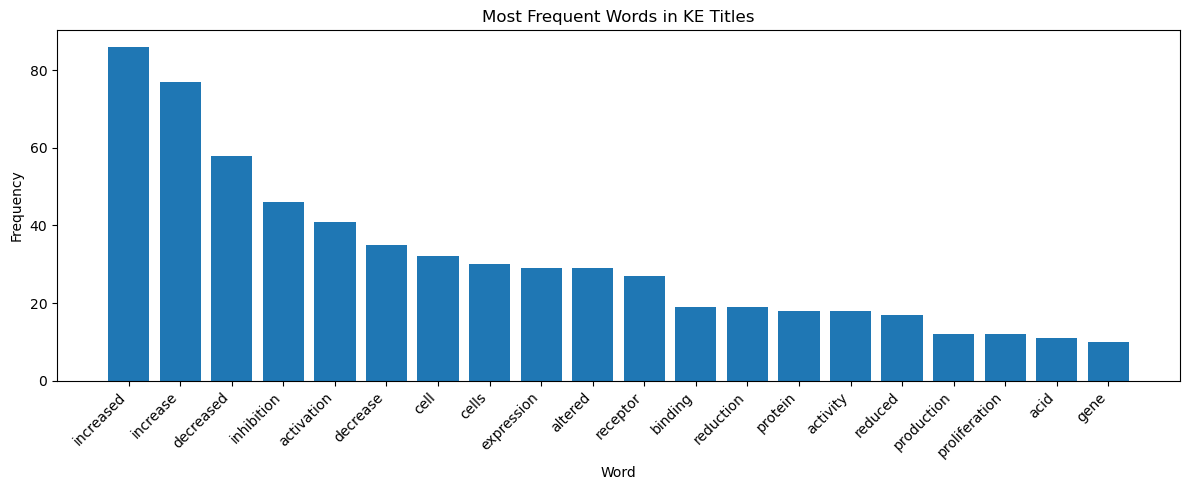

In [131]:
words, counts = zip(*frequent_words)
plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Most Frequent Words in KE Titles")
plt.tight_layout()
plt.show()

In [ ]:
print(stop_words)

{'having', 'but', "doesn't", 'himself', 'hers', 'below', 'we', 'you', 'them', 'just', 'up', 'once', 'of', 'the', "wasn't", 'as', 'they', 'weren', 'some', 'yourselves', "i'd", 'into', 'here', 'was', 'couldn', 'is', 'that', 'mightn', "he'd", "you're", 'own', 'did', 'in', 'who', 'an', 'will', 'or', 'again', 'until', 'isn', 've', 'these', 'more', 'such', 'herself', 'ma', 'aren', 'all', "we're", 'very', 'through', "we've", 'when', 'against', 'theirs', 'it', 'which', "mustn't", 'have', "hadn't", "wouldn't", 'shouldn', "hasn't", 'won', 'd', 'then', 'whom', 'had', 'before', 'myself', "we'd", "should've", 'other', 'ain', 'at', 'o', 'shan', 'now', 'over', 'me', 'during', "he'll", 'needn', 't', 'should', 'why', "he's", 'are', "couldn't", 'each', 'ours', 'most', 'with', 'his', 'has', 'so', 'yourself', 's', 'after', 'hasn', 'if', 'to', 'its', 'being', "shan't", "they've", "weren't", 'on', 'our', 'hadn', 'don', 'from', 'while', 're', "that'll", 'above', 'itself', 'be', "it'd", 'by', "we'll", 'she', 

In [132]:
stop_words.update({"increased", "increase", "decreased", "inhibition", "activation", "decrease"})

### Chunk KE titles into noun phrases

In [133]:
# Define a chunk grammar to identify noun phrases in tagged text
# Pattern 1 : compound noun phrases joined by cunjunctions
# Pattern 2 : simple noun phrases made of adjectives, verbs, nouns, or proper nouns
grammar = r"""
    NP:
        {<JJ|VBN|VBP|NN|MD|NNP.*>+(<CC><NN.*>+)+}
        {<JJ|VBN|VBP|NN|MD|NNP.*>+}
"""

# Initialise the NLTK RegexParser with the defined grammar
chunker = nltk.RegexpParser(grammar)

# Traverse a parsed chunk tree and extract all noun phrases subtrees as plain strings
def extract_chunks(tree) :
    phrases = []
    for subtree in tree.subtrees(filter = lambda t : t.label() == 'NP') :
        # Join the words of each noun phrase leaf node into a single phrase string
        phrase = " ".join(word for word, tag in subtree.leaves())
        phrases.append(phrase)
    return phrases

# Expand "and / or" constructions into 2 separate phrases
def expand_and_or(phrases) :
    expanded = []
    for phrase in phrases : 
        if "and/or" in phrase :
            parts = phrase.split("and/or")
            left = parts[0].strip()  # Left side of "and / or"
            right = parts[1].strip() # Right side of "and / or"
            left_tokens = left.split()
            head = left_tokens[-1]   # Last word (shared head noun)
            modifier = " ".join(left_tokens[:-1])
            expanded.append(f"{modifier} {head}")
            expanded.append(f"{modifier} {right}")
        else : 
            expanded.append(phrase)
    return expanded

# Split a comma-separated string into a list of individual trimmed tokens
# Empty strings resulting from double commas are filtered out
def split_on_comma(text):
    parts = [part.strip() for part in text.split(",")]
    return [p for p in parts if p] 

In [134]:
# Process a list of raw test strings and extract all noun phrases from each
# Return a dict mapping each original text to its list of extracted noun phrases
def process_list_texts(texts):
    results = {}

    for text in texts:
        # Step 1 : split the text on commas to handle items separately
        parts = split_on_comma(text)
        
        all_phrases = []
        for part in parts:
            # Step 2 : tokenise the text segment into individual words / punctuation
            tokens = nltk.word_tokenize(part)
            # Step 3 : assign a POS tag to each token
            pos_tags = nltk.pos_tag(tokens)
            # Step 3.5 : remove stopwords while preserving (word, tag) tuple structure
            pos_tags = [(word, tag) for word, tag in pos_tags 
                        if word.lower() not in stop_words]
            
            # Skip this part if no tokens remain after stopword filtering
            if not pos_tags:
                continue
            # Step 4 : apply the RegexParser to identify noun phrases in the tagged sequence 
            tree = chunker.parse(pos_tags)
            # Step 5 : extract noun phrases as plain strings
            phrases = extract_chunks(tree)
            # Step 6 : expand any "and / or" constructions into 2 distinct phrases
            phrases = expand_and_or(phrases)
            # Step 7 : accumulate phrases from all comma-separated parts
            all_phrases.extend(phrases)
        
        # Map the original text to its full list of extracted noun phrases
        results[text] = all_phrases
    return results

### Semantic matching KE titles noun phrases - MeSH descriptors

In [153]:
# Match extracted KE noun phrases to MeSH descriptors using semantic similarity. 
# Returns a ranked list of KE noun phrases (chunks) - MeSH descriptor pairs.
def match_mesh_ke_chunks(mesh_descriptors, ke_titles, model):

    # Load the model for semantic embedding
    model = SentenceTransformer(model)
    matches = []

    # Extract noun phrases from all KE titles 
    # Returns a dict {ke_title: [chunk1, chunk2 ...]}
    KE_chunks = process_list_texts(ke_titles)

    # Flatten chunks into a list whuile tracking which KE each chunk belongs to
    # Flat list of all noun phrases across all KE titles
    chunk_texts = []
    # Parallel list mapping each noun phrase back to its source KE title
    chunk_to_ke = []
    for ke_title, chunks in KE_chunks.items():
        for chunk in chunks:
            chunk_texts.append(chunk)
            chunk_to_ke.append(ke_title)

    # Encode all KE chunks and MeSH descriptors into dense vector embeddings
    chunk_embeddings = model.encode(chunk_texts, convert_to_tensor=True)
    mesh_embeddings = model.encode(mesh_descriptors, convert_to_tensor=True)

    # For each KE chunk, compute cosine similarity against all MeSH descriptors and
    # retain the top 8 closest matches
    for idx, (ke, ke_emb) in enumerate(zip(chunk_texts, chunk_embeddings)):
        # Cosine similarity scores between this chunk and every MeSH descriptor
        scores = util.cos_sim(ke_emb, mesh_embeddings)[0]

        # Get indices of the top 8 highest-scoring MeSH descriptors
        top_indices = scores.topk(8).indices

        # Record each top match as a structured result entry
        for id in top_indices:
            matches.append({
                "KE_TITLE": chunk_to_ke[idx], 
                "KE_CHUNK": ke,
                "MESH_TITLE": mesh_descriptors[id],
                "SCORE": scores[id].item()
            })

    return matches

In [154]:
# Remove descriptors from branches K, L
ids_KL = set(MeSH_branches[MeSH_branches["MESH_BRANCH"].isin(["K", "L"])]["MESH_ID"])
filtered_MeSH_descriptors = MeSH_descriptors[~MeSH_descriptors["MESH_ID"].isin(ids_KL)]
# Convert filtered descriptors to list
filtered_MeSH_descriptors_titles = filtered_MeSH_descriptors["MESH_TITLE"].unique().tolist()

In [155]:
# all-MiniLM-L6-v2
results = match_mesh_ke_chunks(filtered_MeSH_descriptors_titles, ke_titles_description, model = "all-MiniLM-L6-v2")
res_KE_chunks_allMiniLM = pd.DataFrame(results)

In [156]:
# BioBERT
results = match_mesh_ke_chunks(filtered_MeSH_descriptors_titles, ke_titles_description, model = "pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")
res_KE_chunks_biobert = pd.DataFrame(results)

In [157]:
# SciBERT
results = match_mesh_ke_chunks(filtered_MeSH_descriptors_titles, ke_titles_description, model = "allenai/scibert_scivocab_uncased")
res_KE_chunks_scibert = pd.DataFrame(results)

No sentence-transformers model found with name /home/mmathe/.cache/torch/sentence_transformers/allenai_scibert_scivocab_uncased. Creating a new one with MEAN pooling.
Some weights of the model checkpoint at /home/mmathe/.cache/torch/sentence_transformers/allenai_scibert_scivocab_uncased were not used when initializing BertModel: ['cls.predictions.decoder.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly 

In [158]:
# SapBERT
results = match_mesh_ke_chunks(filtered_MeSH_descriptors_titles, ke_titles_description, model = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext")
res_KE_chunks_sapbert = pd.DataFrame(results)

No sentence-transformers model found with name /home/mmathe/.cache/torch/sentence_transformers/cambridgeltl_SapBERT-from-PubMedBERT-fulltext. Creating a new one with MEAN pooling.


In [159]:
# BiomedBERT
results = match_mesh_ke_chunks(filtered_MeSH_descriptors_titles, ke_titles_description, model = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract")
res_KE_chunks_biomedbert = pd.DataFrame(results)

No sentence-transformers model found with name /home/mmathe/.cache/torch/sentence_transformers/microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract. Creating a new one with MEAN pooling.
Some weights of the model checkpoint at /home/mmathe/.cache/torch/sentence_transformers/microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract were not used when initializing BertModel: ['cls.predictions.decoder.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint o

In [145]:
# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
res_KE_chunks_biobert = MeSH_descriptors.merge(res_KE_chunks_biobert, on = "MESH_TITLE")
res_KE_chunks_allMiniLM = MeSH_descriptors.merge(res_KE_chunks_allMiniLM, on = "MESH_TITLE")
res_KE_chunks_scibert = MeSH_descriptors.merge(res_KE_chunks_scibert, on = "MESH_TITLE")
res_KE_chunks_sapbert = MeSH_descriptors.merge(res_KE_chunks_sapbert, on = "MESH_TITLE")
res_KE_chunks_biomedbert = MeSH_descriptors.merge(res_KE_chunks_biomedbert, on = "MESH_TITLE")

# Merge with the AOP KE dataframe to map each KE_TITLE to the corresponding KE_ID
res_KE_chunks_biobert = AOP_KEs_description.merge(res_KE_chunks_biobert, on = "KE_TITLE")
res_KE_chunks_allMiniLM = AOP_KEs_description.merge(res_KE_chunks_allMiniLM, on = "KE_TITLE")
res_KE_chunks_scibert = AOP_KEs_description.merge(res_KE_chunks_scibert, on = "KE_TITLE")
res_KE_chunks_sapbert = AOP_KEs_description.merge(res_KE_chunks_sapbert, on = "KE_TITLE")
res_KE_chunks_biomedbert = AOP_KEs_description.merge(res_KE_chunks_biomedbert, on = "KE_TITLE")

In [146]:
# Structure indexing results
# Tag each result dataframe with the name of the model that produced it
res_KE_chunks_allMiniLM['MODEL'] = "allMiniLM"
res_KE_chunks_biobert['MODEL'] = "biobert"
res_KE_chunks_scibert['MODEL'] = "scibert"
res_KE_chunks_sapbert['MODEL'] = "sapbert"
res_KE_chunks_biomedbert['MODEL'] = "biomedbert"

# Concatenate all per-model result dataframes into a single dataframe
# ignore_index = True resets the row index to avoid duplicate indices across sources
all_res_KE_chunks = pd.concat([
    res_KE_chunks_allMiniLM,
    res_KE_chunks_biobert,
    res_KE_chunks_scibert,
    res_KE_chunks_sapbert,
    res_KE_chunks_biomedbert
], ignore_index = True)

# Merge with the MeSH branch dataframe to map each MESH_BRANCH to the corresponding MESH_ID
res_KE_chunks_allMiniLM = MeSH_branches.merge(res_KE_chunks_allMiniLM, on = "MESH_ID")

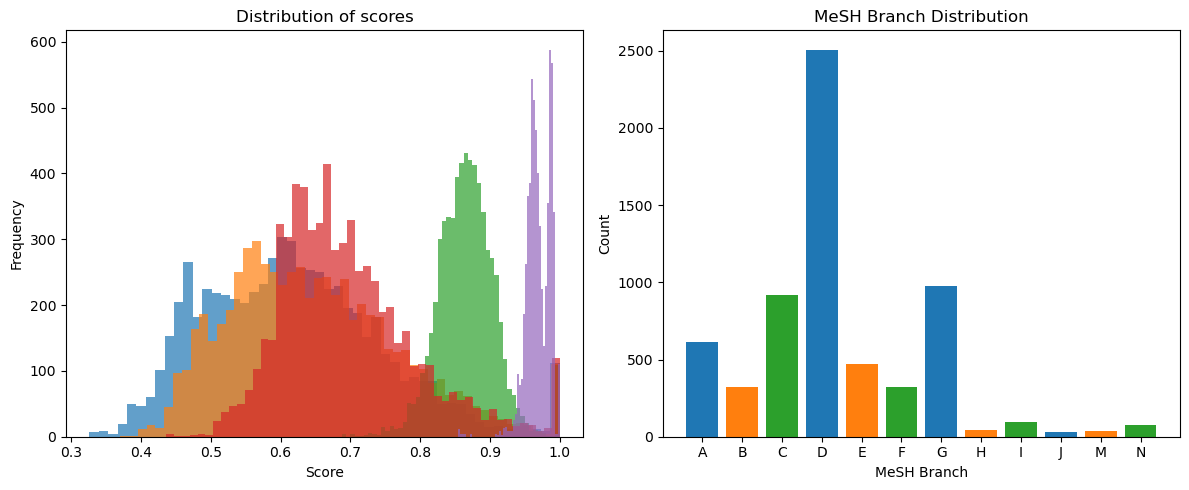

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = all_res_KE_chunks['MODEL'].unique()
colors = ['C0', 'C1', 'C2', 'C3', 'C4'] 

for i, model in enumerate(models):
    scores = all_res_KE_chunks[all_res_KE_chunks['MODEL'] == model]['SCORE']
    axes[0].hist(scores, bins = 50, alpha = 0.7, label = model, color = colors[i])
axes[0].set_title("Distribution of scores")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")

freq = Counter(res_KE_chunks_allMiniLM["MESH_BRANCH"])
labels = sorted(freq.keys())
counts = [freq[k] for k in labels]

axes[1].bar(labels, counts, color=["C0", "C1", "C2"])
axes[1].set_xlabel("MeSH Branch")
axes[1].set_ylabel("Count")
axes[1].set_title("MeSH Branch Distribution")

plt.tight_layout()
plt.show()

### Evaluate performance compared to indexing on descriptions

allMiniLM
Average F1: 0.278
Average Recall: 0.766
biobert
Average F1: 0.304
Average Recall: 0.748
biomedbert
Average F1: 0.142
Average Recall: 0.649
sapbert
Average F1: 0.308
Average Recall: 0.705
scibert
Average F1: 0.179
Average Recall: 0.715


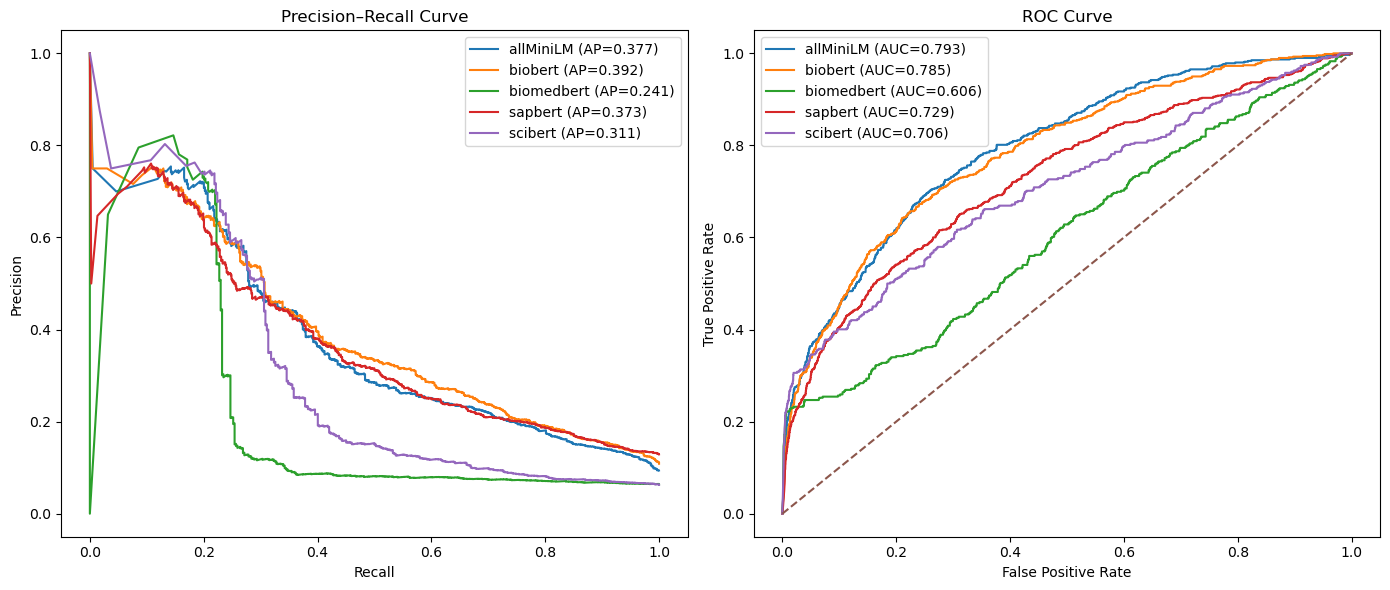

In [148]:
evaluation_metrics_models(indexing_results_dataframe, all_res_KE_chunks)

- BioBERT is the best overall model with the highest F1, highest average precision, and highest ROC AUC. 
- High recall across top models is expected given the top 7 retrieval strategy : the models are designed to cast a wide net, favoring recall over precision.  
- Precision remains low across all models : a significant part of the top 7 matches are still noise. 

### Get all matches for AllMiniLM and BioBERT

## 8. Benchmark top matches to keep

### Top N matches

In [149]:
def top_n_matches(results, n):
    top_n_results = []
    for ke in results["KE_TITLE"].unique():
        kes = results[results["KE_TITLE"] == ke]
        top_n = kes.nlargest(n, "SCORE")
        top_n_results.append(top_n)

    return pd.concat(top_n_results, ignore_index=True)

In [150]:
def compute_metrics_per_n(baseline, results_15, n_range=range(1, 8)):
    records = []

    # Build an index from the ground truth (baseline) for fast membership testing
    baseline_index = baseline.set_index(["MESH_ID", "KE_ID"]).index

    for n in n_range:
        # Retrieve only the top-n scoring MeSH descriptors matches per KE
        df = top_n_matches(results_15, n=n).copy()

        # Label each (MESH_ID, KE_ID) pair as 1 if it appears in the baseline, 0 otherwise
        df["true"] = (
            df.set_index(["MESH_ID", "KE_ID"]).index
            .isin(baseline_index)
            .astype(int)
        )
        y_true   = df["true"]
        y_scores = df["SCORE"]

        # Average precision
        ap = metrics.average_precision_score(y_true, y_scores)

        # ROC AUC
        fpr, tpr, _ = metrics.roc_curve(y_true, y_scores)
        auc = metrics.auc(fpr, tpr)

        # Average F1
        precision, recall, _ = metrics.precision_recall_curve(y_true, y_scores)
        f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
        avg_f1 = np.mean(f1_scores)

        # Average recall
        avg_recall = np.mean(recall)

        records.append({"n": n, "AP": ap, "AUC": auc, "F1": avg_f1, "Recall": avg_recall})

    return pd.DataFrame(records)


metrics_miniLM  = compute_metrics_per_n(indexing_results_dataframe, res_KE_chunks_allMiniLM)
metrics_biobert = compute_metrics_per_n(indexing_results_dataframe, res_KE_chunks_biobert)
metrics_scibert = compute_metrics_per_n(indexing_results_dataframe, res_KE_chunks_scibert)
metrics_sapbert = compute_metrics_per_n(indexing_results_dataframe, res_KE_chunks_sapbert)
metrics_biomedbert = compute_metrics_per_n(indexing_results_dataframe, res_KE_chunks_biomedbert)

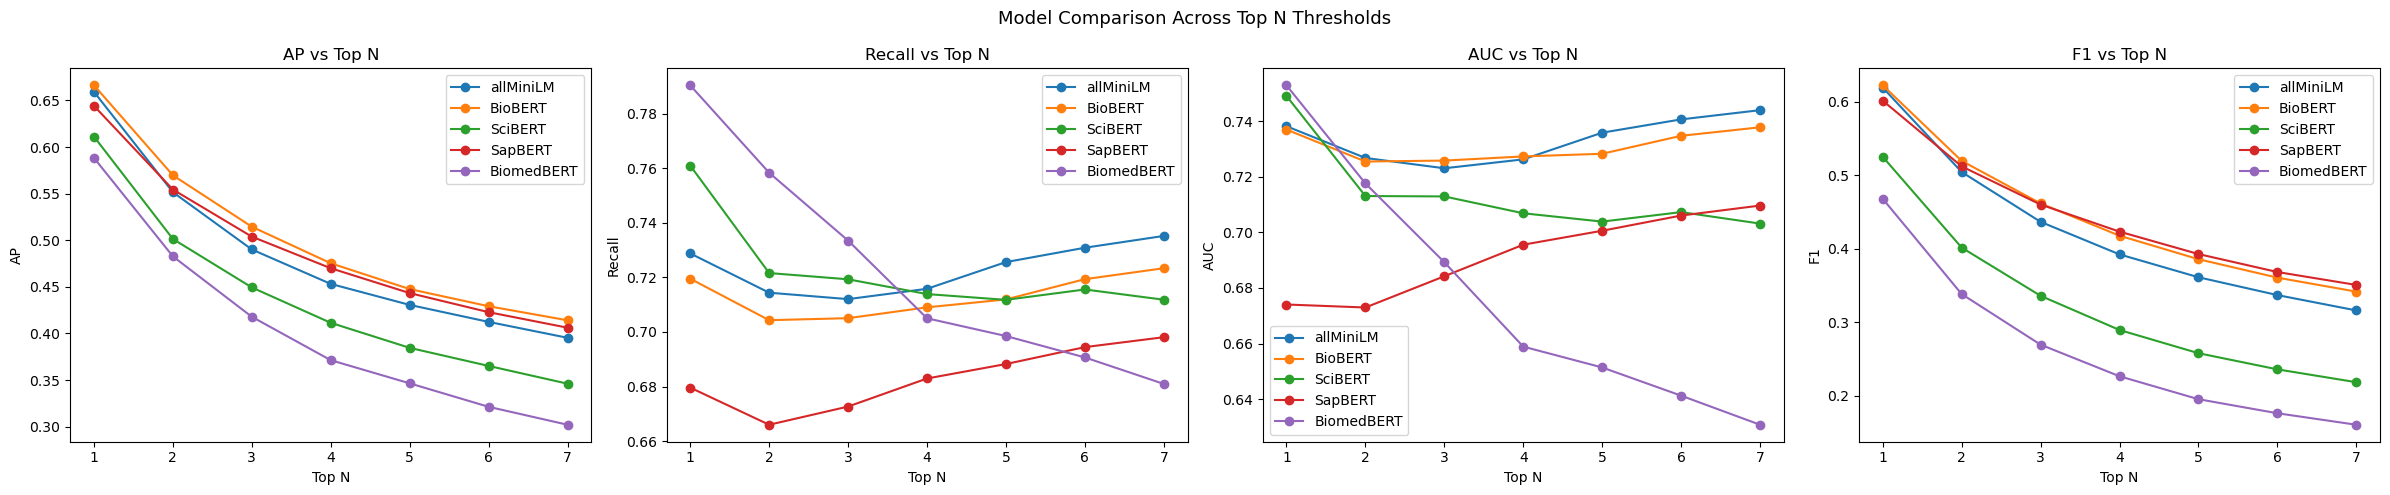

In [151]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
ns = list(range(1, 8))

for metric, ax in zip(["AP", "Recall", "AUC", "F1"], axes):
    ax.plot(ns, metrics_miniLM[metric].to_numpy(),  marker="o", label="allMiniLM")
    ax.plot(ns, metrics_biobert[metric].to_numpy(), marker="o", label="BioBERT")
    ax.plot(ns, metrics_scibert[metric].to_numpy(), marker="o", label="SciBERT")
    ax.plot(ns, metrics_sapbert[metric].to_numpy(), marker="o", label="SapBERT")
    ax.plot(ns, metrics_biomedbert[metric].to_numpy(), marker="o", label="BiomedBERT")
    ax.set_xlabel("Top N")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs Top N")
    ax.legend()

plt.suptitle("Model Comparison Across Top N Thresholds", fontsize=13)
plt.tight_layout()
plt.show()

top 3 + biobert 
--> PR curve + ROC AUC + nb of KEs / MeSH + branches 

In [ ]:
res_KE_chunks_biobert_top3 = top_n_matches(res_KE_chunks_biobert, 3)
res_KE_chunks_biobert_top3 = MeSH_branches.merge(res_KE_chunks_biobert_top3, on = "MESH_ID")

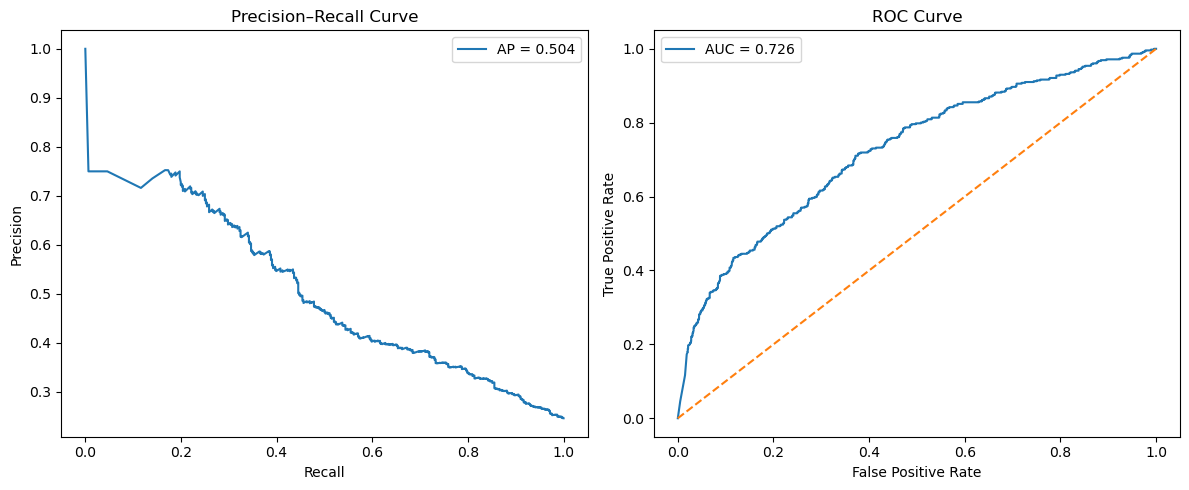

Average F1: 0.449
Average Recall: 0.708


In [ ]:
evaluation_metrics(indexing_results_dataframe, res_KE_chunks_biobert_top3)

In [ ]:
# baseline (= indexing results)
baseline_sem = res_KE_chunks_biobert_top3.groupby("KE_ID")["KE_CHUNK"].apply(set)

# compute nb of MeSH ID / KE
num_mesh_per_ke = baseline_sem.apply(len)

# summary statistics
print("Min number of chunks per KE:", num_mesh_per_ke.min())
print("Max number of chunks per KE:", num_mesh_per_ke.max())
print("Mean:", num_mesh_per_ke.mean())
print("Median:", num_mesh_per_ke.median())

Min number of chunks per KE: 1
Max number of chunks per KE: 2
Mean: 1.1474878444084278
Median: 1.0


In [ ]:
# baseline (= indexing results)
baseline = res_KE_chunks_biobert_top3.groupby("KE_ID")["MESH_ID"].apply(set)

# compute nb of MeSH ID / KE
num_mesh_per_ke = baseline.apply(len)

# summary statistics
print("Min number of mesh IDs per KE:", num_mesh_per_ke.min())
print("Max number of mesh IDs per KE:", num_mesh_per_ke.max())
print("Mean:", num_mesh_per_ke.mean())
print("Median:", num_mesh_per_ke.median())

Min number of mesh IDs per KE: 3
Max number of mesh IDs per KE: 3
Mean: 3.0
Median: 3.0


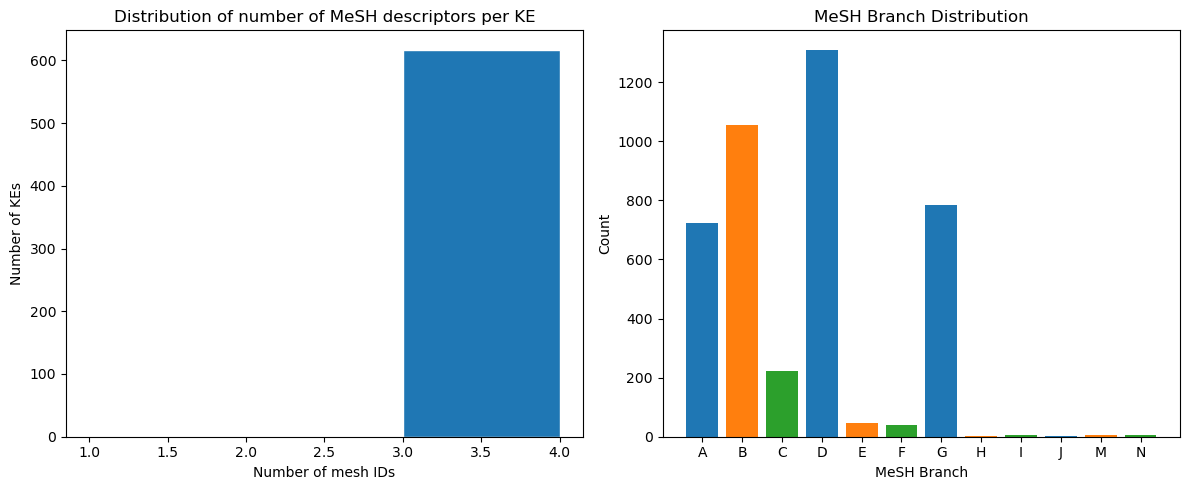

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(num_mesh_per_ke, bins=range(1, num_mesh_per_ke.max()+2), edgecolor='white', color = "C0")
axes[0].set_title("Distribution of number of MeSH descriptors per KE")
axes[0].set_xlabel("Number of mesh IDs")
axes[0].set_ylabel("Number of KEs")

freq = Counter(indexing_results_dataframe["MESH_BRANCH"])
labels = sorted(freq.keys())
counts = [freq[k] for k in labels]

axes[1].bar(labels, counts, color=["C0", "C1", "C2"])
axes[1].set_xlabel("MeSH Branch")
axes[1].set_ylabel("Count")
axes[1].set_title("MeSH Branch Distribution")

plt.tight_layout()
plt.show()

### Score threshold

## 9. Generate synthetic descriptions and perform indexing

## 10. Run POS tagging and semantic matching for KEs without description

In [ ]:
# BioBERT
results = match_mesh_ke_chunks(filtered_MeSH_descriptors_titles, ke_titles_no_description, model = "pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")
res_KE_chunks_biobert_noD = pd.DataFrame(results)

In [ ]:
res_KE_chunks_biobert_noD = MeSH_descriptors.merge(res_KE_chunks_biobert_noD, on = "MESH_TITLE")
res_KE_chunks_biobert_noD = AOP_KEs_no_description.merge(res_KE_chunks_biobert_noD, on = "KE_TITLE")

In [ ]:
res_KE_chunks_biobert_top3_noD = top_n_matches(res_KE_chunks_biobert_noD, 3)
res_KE_chunks_biobert_top3_noD = MeSH_branches.merge(res_KE_chunks_biobert_top3_noD, on = "MESH_ID")

## 11. Prepare results data table

In [ ]:
# concatenate all results together
# columns : AOP ID | AOP TITLE | KE ID | KE TITLE | MESH ID | MESH TITLE

indexing = indexing_results_dataframe[["MESH_ID", "KE_ID"]]
indexing = MeSH_descriptors.merge(indexing, on = "MESH_ID")
indexing = AOP_KEs_description[["KE_ID", "KE_TITLE"]].merge(indexing, on = "KE_ID")
indexing = KE_to_AOP.merge(indexing, on = "KE_ID")
indexing = indexing[["AOP_ID", "AOP_TITLE", "KE_ID", "KE_TITLE", "MESH_ID", "MESH_TITLE"]]

In [ ]:
matching = res_KE_chunks_biobert_top3_noD[["MESH_ID", "KE_ID"]]
matching = MeSH_descriptors.merge(matching, on = "MESH_ID")
matching = AOP_KEs_no_description[["KE_ID", "KE_TITLE"]].merge(matching, on = "KE_ID")
matching = KE_to_AOP.merge(matching, on = "KE_ID")
matching = matching[["AOP_ID", "AOP_TITLE", "KE_ID", "KE_TITLE", "MESH_ID", "MESH_TITLE"]]

In [ ]:
AOP_MeSH_mappings = pd.concat([indexing, matching], ignore_index=True)

## 12. Downstream analysis

### Key Events annotated with only one MeSH descriptor

In [ ]:
# Count MeSH descriptors per KE
mesh_counts = AOP_MeSH_mappings.groupby("KE_ID")["MESH_ID"].nunique()

# Filter KEs with only one unique MeSH descriptor
single_mesh_KEs = mesh_counts[mesh_counts == 1].index

# Apply filter to the mappings dataframe
KEs_with_single_MeSH = AOP_MeSH_mappings[AOP_MeSH_mappings["KE_ID"].isin(single_mesh_KEs)]

print(KEs_with_single_MeSH.shape)

(8, 6)


In [ ]:
print(KEs_with_single_MeSH[["KE_TITLE", "MESH_TITLE"]])

                                                KE_TITLE MESH_TITLE
1716                                            N/A, Gap     Humans
2269   Binding to estrogen receptor (ER)-α in immune ...    Animals
8601                            Protein Adduct Formation   Proteins
9271                Increase, Phenotypic enzyme activity     Humans
11870                Increase, Cytotoxicity (club cells)     Humans
11879  Inhibition, 4-hydroxyphenyl-pyruvate dioxygena...     Humans
11880          Increase, Cytotoxicity (epithelial cells)     Humans
13036          Increase, Cytotoxicity (epithelial cells)     Humans


### KEs annotated with a unique set of MeSH (no other KE shares the exact same MeSH set)

In [ ]:
# Get the set of MeSH descriptors per KE as a frozenset (hashable)
ke_mesh_sets = (
    AOP_MeSH_mappings.drop_duplicates(subset=["KE_ID", "MESH_ID"])
    .groupby("KE_ID")["MESH_ID"]
    .apply(frozenset)
)

# Count how many KEs share each MeSH set
mesh_set_counts = ke_mesh_sets.value_counts()

# KEs with a unique MeSH set (not shared by any other KE)
unique_sets = mesh_set_counts[mesh_set_counts == 1].index
nb_KEs_unique_mesh_set = ke_mesh_sets[ke_mesh_sets.isin(unique_sets)].count()
print(f"KEs with a unique MeSH set: {nb_KEs_unique_mesh_set}")

KEs with a unique MeSH set: 1287


In [ ]:
# Reuse ke_mesh_sets from above
# Map each KE to its MeSH set, then group KEs by shared set
ke_mesh_sets_df = ke_mesh_sets.reset_index()
ke_mesh_sets_df.columns = ["KE_ID", "MESH_set"]

# Groups of KEs sharing the exact same MeSH set
shared_groups = (
    ke_mesh_sets_df.groupby("MESH_set")["KE_ID"]
    .apply(list)
    .reset_index()
)
shared_groups["nb_KEs"] = shared_groups["KE_ID"].apply(len)

# Keep only groups where more than one KE shares the same set
duplicated_groups = shared_groups[shared_groups["nb_KEs"] > 1]
print(f"Nb of MeSH sets shared by multiple KEs: {len(duplicated_groups)}")
print(f"Nb of KEs involved: {duplicated_groups['nb_KEs'].sum()}")

Nb of MeSH sets shared by multiple KEs: 104
Nb of KEs involved: 282


In [ ]:
ke_mesh_sets_titled = (
    AOP_MeSH_mappings.drop_duplicates(subset=["KE_ID", "MESH_ID"])
    .groupby("KE_ID")
    .apply(lambda x: frozenset(zip(x["MESH_ID"], x["MESH_TITLE"])))
)

ke_mesh_sets_df = ke_mesh_sets_titled.reset_index()
ke_mesh_sets_df.columns = ["KE_ID", "MESH_set"]
ke_mesh_sets_df = ke_mesh_sets_df.merge(
    AOP_MeSH_mappings[["KE_ID", "KE_TITLE"]].drop_duplicates(), on="KE_ID"
)

shared_groups = (
    ke_mesh_sets_df.groupby("MESH_set")
    .apply(lambda x: list(zip(x["KE_ID"], x["KE_TITLE"])))
    .reset_index()
)
shared_groups.columns = ["MESH_set", "KEs"]
shared_groups["nb_KEs"] = shared_groups["KEs"].apply(len)
duplicated_groups = shared_groups[shared_groups["nb_KEs"] > 1]

for _, row in duplicated_groups.iterrows():
    mesh_titles = {title for _, title in row["MESH_set"]}
    print(f"MeSH set : {mesh_titles}")
    for ke_id, ke_title in row["KEs"]:
        print(f"  - KE {ke_id} | {ke_title}")
    print()

MeSH set : {'Animals', 'Humans'}
  - KE https://identifiers.org/aop.events/2263 |  Lysolecithin, increased
  - KE https://identifiers.org/aop.events/2370 | Antagonism binding, α1-Adrenoreceptor 
  - KE https://identifiers.org/aop.events/584 | Inhibition, sodium channel

MeSH set : {'Diet, Reducing', 'Reducing Agents', 'Reduced Folate Carrier Protein'}
  - KE https://identifiers.org/aop.events/2223 | Reduced number of oligodendrocytes
  - KE https://identifiers.org/aop.events/972 | Decreased fertility, Reduced number of oocytes ovulated 

MeSH set : {'Binding Sites', 'Receptors, Pituitary Hormone-Regulating Hormone', 'Receptors, Pituitary Hormone'}
  - KE https://identifiers.org/aop.events/2216 | Binding of antagonist to thyroid hormone receptor
  - KE https://identifiers.org/aop.events/2217 | Binding of antagonist to glucocorticoid hormone receptor

MeSH set : {'11-beta-Hydroxysteroid Dehydrogenase Type 1', '11-beta-Hydroxysteroid Dehydrogenases', '11-beta-Hydroxysteroid Dehydrogenase 

/tmp/ipykernel_268602/2464114131.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: frozenset(zip(x["MESH_ID"], x["MESH_TITLE"])))
/tmp/ipykernel_268602/2464114131.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: list(zip(x["KE_ID"], x["KE_TITLE"])))


In [ ]:
print(f"Mean KEs sharing the same MeSH set: {duplicated_groups['nb_KEs'].mean():.2f}")
print(f"Median: {duplicated_groups['nb_KEs'].median():.2f}")
print(f"Max: {duplicated_groups['nb_KEs'].max()}")

Mean KEs sharing the same MeSH set: 2.71
Median: 2.00
Max: 22
